# Two-neutrino probabilities

Oscillation probabilities in a two-flavour system, against energy and against direction, in seven settings: vacuum, constant density, an exponential and a Gaussian profile, a periodic castle wall, a noisy profile, and then the Earth and the Sun.

Each is validated against the closed-form expression where one exists, which is what makes this the notebook to read before trusting any of the others.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.oscprobstd as oscprobstd
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

# Best-fit oscillation parameters from the latest global fit.
# load_nufit_params returns exactly the six parameters the
# osc_prob_3nu_* functions take, so it can be splatted straight in.
NUFIT_NO = gd.load_nufit_params('NuFIT 6.1', 'NO')
import magnus.plotting as plotting

# 0. Helper functions and definitions

In [3]:
col_full = '#E76F51'
col_ang = '#2A9D8F'
col_en = '#E9C46A'
col_count = '#73A8BF'#'#2A9D8F'

In [4]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

# 1. Probabilities 2$\nu$: in vacuum

## 1.1 General definitions

In [5]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = NUFIT_NO['s12'] # [adim]
Dm2 = NUFIT_NO['D21'] # [eV^2]

## 1.2 Probabilities vs. distance

### Generate probabilities

In [6]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# Both probabilities are computed for the *whole* array of baselines in a single
# call, which is the form to prefer: measured here, the array call takes 0.95 s
# against 1.57 s for a Python loop that calls osc_prob once per point (1.7x).
#
# The margin is that modest, rather than an order of magnitude, because what a
# call costs is mostly the integration it performs -- not a fixed entry-path
# overhead paid per call. On a profile that actually varies, the same call
# measures 0.34 ms at n_slabs=1 and 10.4 ms at n_slabs=2000. Batching amortizes
# the entry path, which is real but small; it cannot make the physics cheaper.

# Using the standard formula
prob_std = oscprobstd.osc_prob_2nu_vacuum_std(
    sth, Dm2, energy, distances*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion
prob = oscprob.osc_prob_2nu_vacuum(
    energy, distances*gd.CONV_KM_TO_INV_EV, sth, Dm2, nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

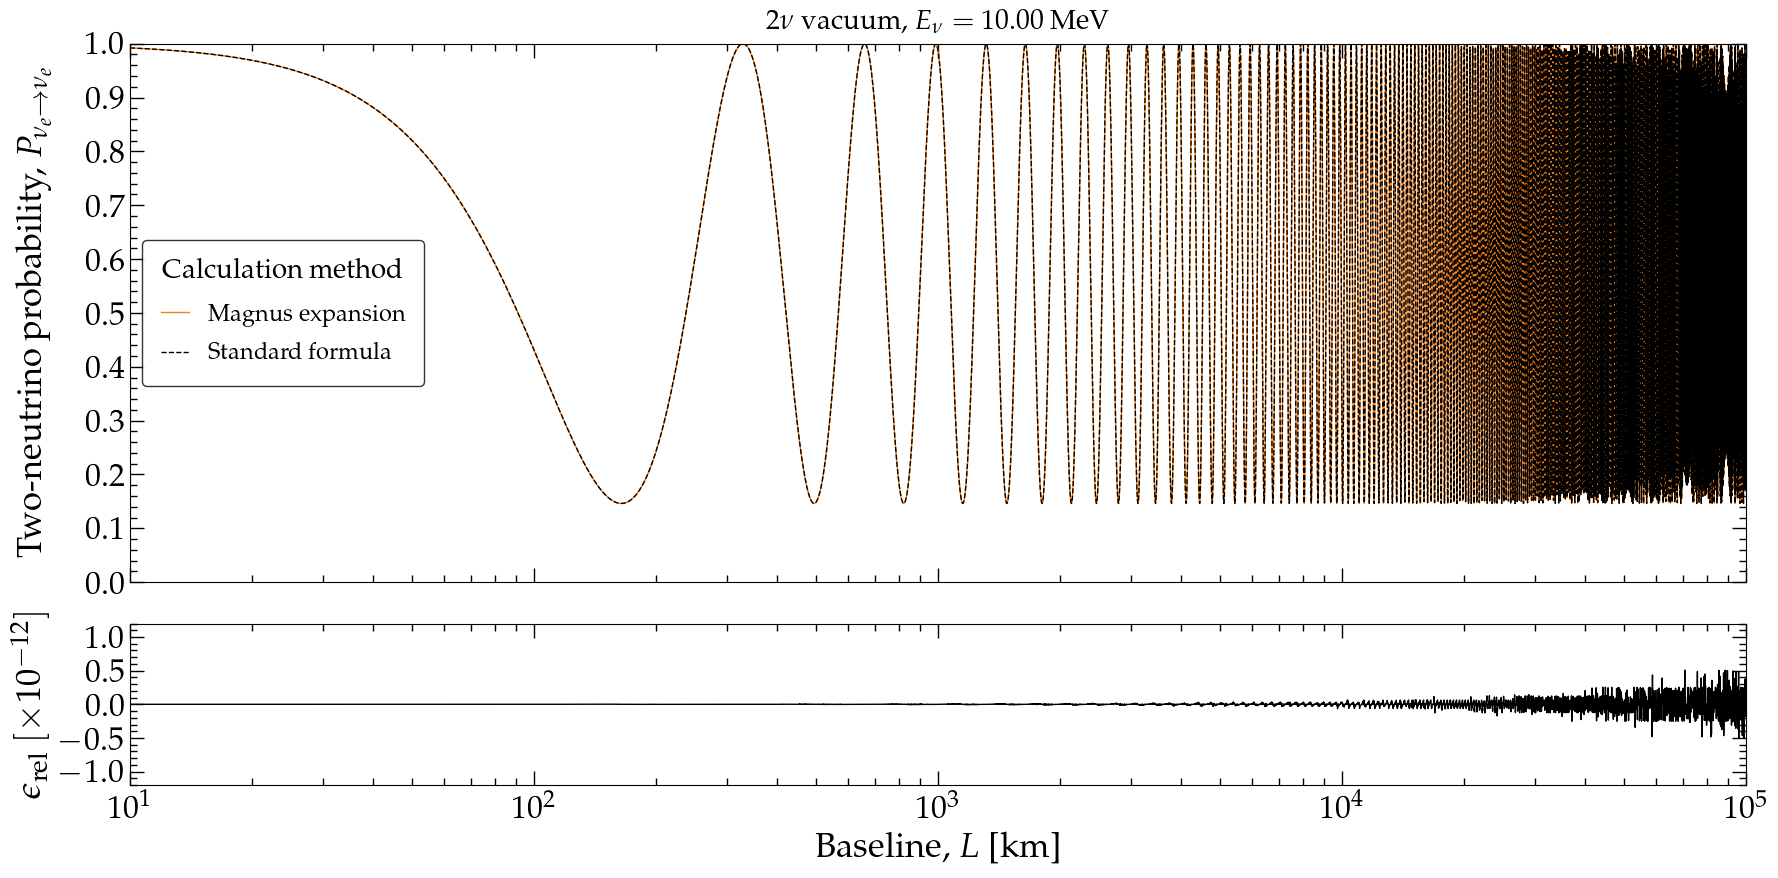

In [7]:
fig, ax = plotting.plot_probability_vs_baseline(
    distances,
    [dict(y=prob, label='Magnus expansion', color='C1'),
     dict(y=prob_std, label='Standard formula', color='k', ls='--')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2,
    xlim=(l_ini, l_fin),
    residual=(prob-prob_std)/prob_std/1.e-12,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-12}]$',
    residual_ylim=(-1.2, 1.2), residual_ymajor=0.50, residual_yminor=0.10,
    legend_title=r'Calculation method', legend_loc='center left',
    title=r'$2\nu$~vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    savefig='../fig/prob_2nu_vacuum_vs_baseline.pdf')

## 1.3 Probabilities vs. energy

### Generate probabilities

In [8]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]

# Both probabilities are computed for the *whole* array of energies in a single
# call, which is the form to prefer: measured here, the array call takes 0.59 s
# against 0.80 s for a Python loop that calls osc_prob once per point (1.4x).
#
# The margin is that modest, rather than an order of magnitude, because what a
# call costs is mostly the integration it performs -- not a fixed entry-path
# overhead paid per call. On a profile that actually varies, the same call
# measures 0.34 ms at n_slabs=1 and 10.4 ms at n_slabs=2000. Batching amortizes
# the entry path, which is real but small; it cannot make the physics cheaper.

# Using the standard formula
prob_std = oscprobstd.osc_prob_2nu_vacuum_std(
    sth, Dm2, energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion
prob = oscprob.osc_prob_2nu_vacuum(
    energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV, sth, Dm2,
    nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

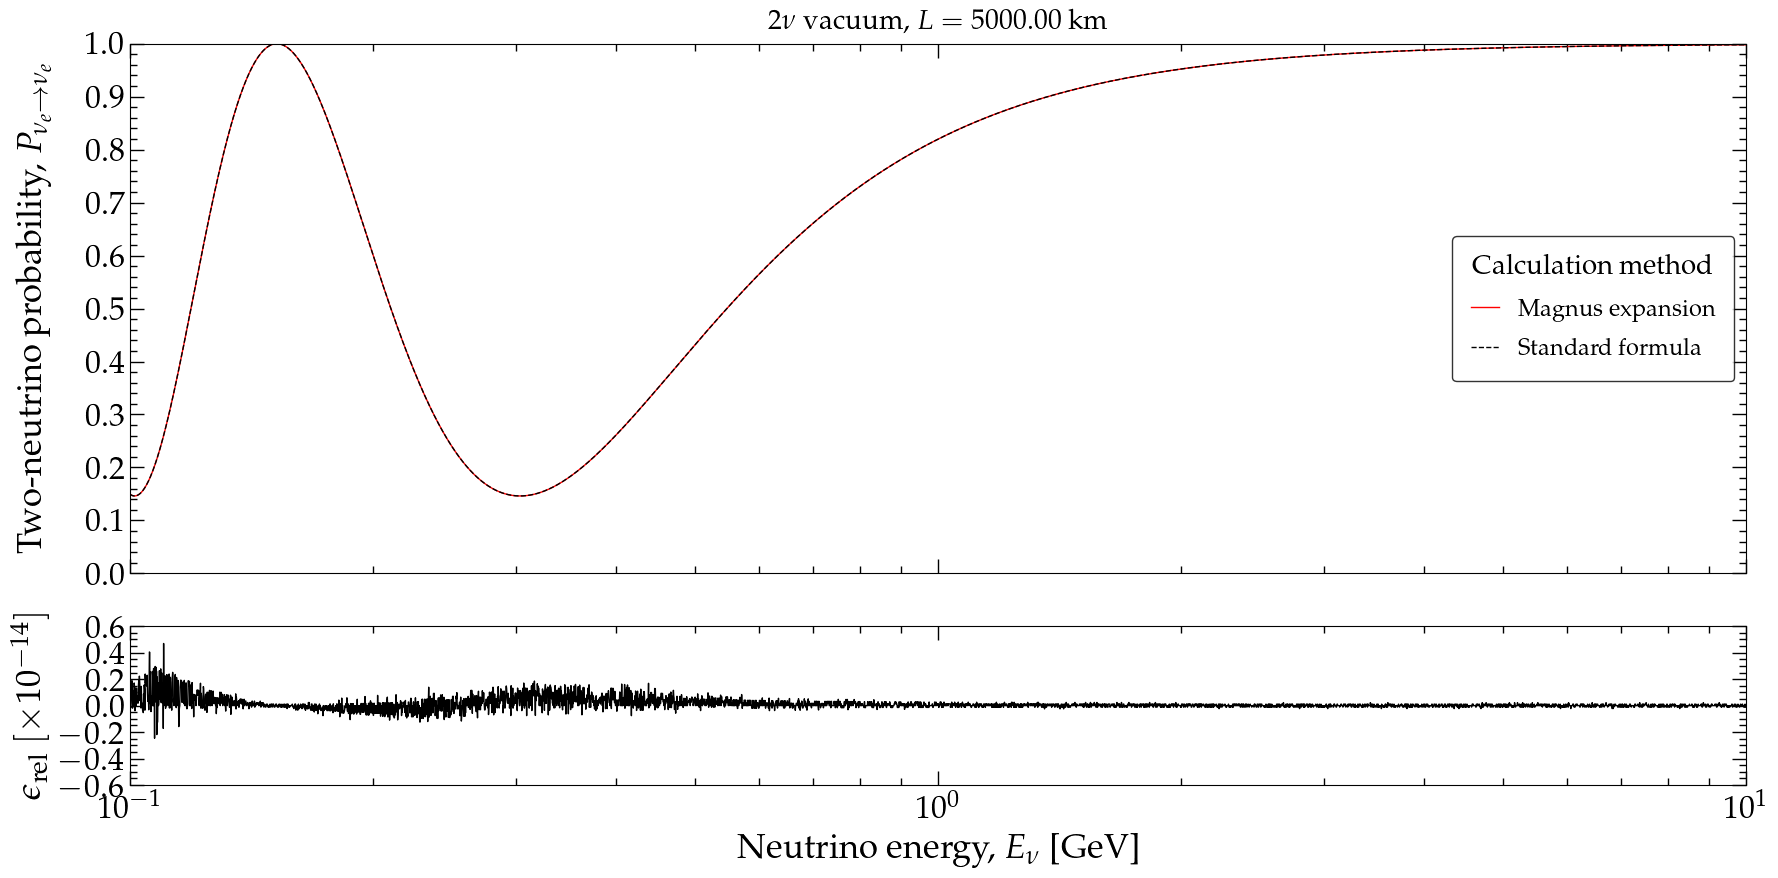

In [9]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob, label='Magnus expansion', color='r'),
     dict(y=prob_std, label='Standard formula', color='k', ls='--')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2,
    xlim=(energy_min, energy_max),
    residual=(prob-prob_std)/prob_std/1.e-14,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-14}]$',
    residual_ylim=(-0.6, 0.6), residual_ymajor=0.20, residual_yminor=0.05,
    legend_title=r'Calculation method', legend_loc='center right',
    title=r'$2\nu$~vacuum, $L = $~{:.2f}~km'.format(baseline),
    savefig='../fig/prob_2nu_vacuum_vs_energy.pdf')

# 2. Probabilities 2$\nu$: in matter with constant density

## 2.1 General definitions

In [10]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = NUFIT_NO['s12'] # [adim]
Dm2 = NUFIT_NO['D21'] # [eV^2]

## 2.2 Probabilities vs. distance

### Generate probabilities

In [11]:
# Baselines
l_ini, l_fin = 1.e1, 1.e5 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
# The potential is still built by hand here, because the standard formula below
# needs it explicitly. Note density_matter_is_in_g_per_cm3=True: without it, rho
# is taken to be in internal units already and the potential comes out ~4e18
# times too small, which looks exactly like having no matter at all.
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho,
                                          electron_fraction=0.5,
                                          density_matter_is_in_g_per_cm3=True) # [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # [eV]

# Both probabilities are computed for the *whole* array of baselines in a single
# call, which is the form to prefer: measured here, the array call takes 1.61 s
# against 3.20 s for a Python loop that calls osc_prob once per point (2.0x).
#
# The margin is that modest, rather than an order of magnitude, because what a
# call costs is mostly the integration it performs -- not a fixed entry-path
# overhead paid per call. On a profile that actually varies, the same call
# measures 0.34 ms at n_slabs=1 and 10.4 ms at n_slabs=2000. Batching amortizes
# the entry path, which is real but small; it cannot make the physics cheaper.

# Using the standard formula
prob_matt_std = oscprobstd.osc_prob_2nu_matter_std(
    sth, Dm2, VCC, energy, distances*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion. The wrapper takes the density directly and builds
# the potential itself, so the matter Hamiltonian never has to be assembled by
# hand -- and its sign cannot be got wrong.
prob_matt = oscprob.osc_prob_2nu_matter_constant_density(
    energy, distances*gd.CONV_KM_TO_INV_EV, rho, sth, Dm2,
    density_matter_is_in_g_per_cm3=True, nu_i=nu_i, nu_f=nu_f)

# In vacuum, for comparison
prob_vac = oscprob.osc_prob_2nu_vacuum(
    energy, distances*gd.CONV_KM_TO_INV_EV, sth, Dm2, nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

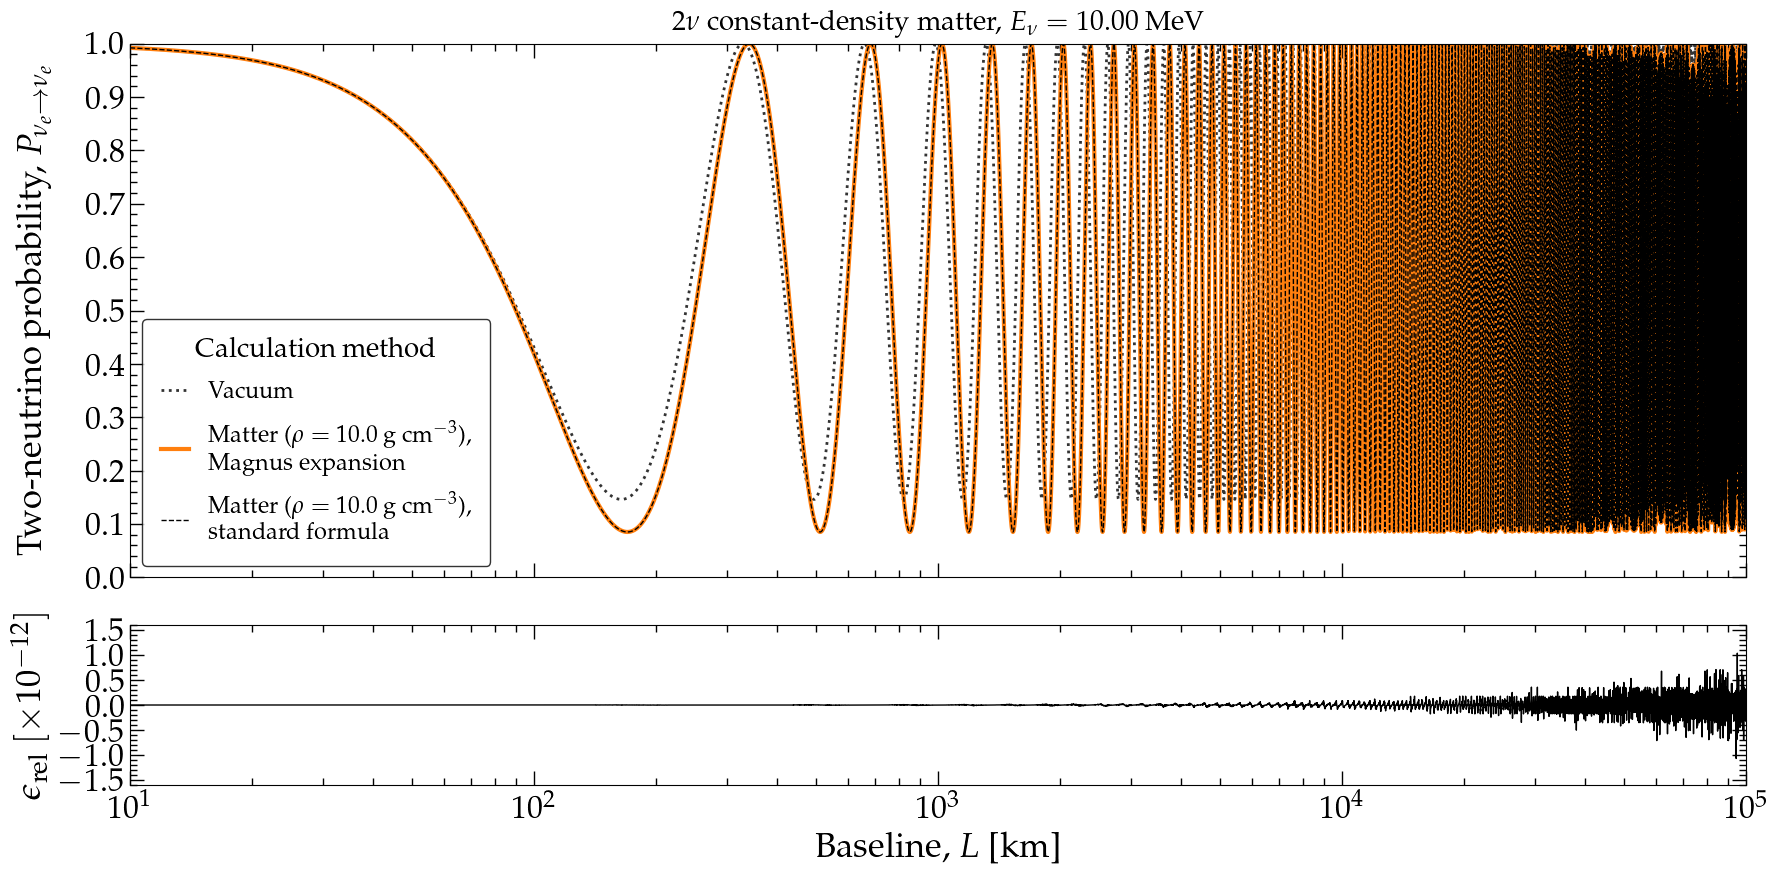

In [12]:
fig, ax = plotting.plot_probability_vs_baseline(
    distances,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', ls=':', lw=2),
     dict(y=prob_matt, color='C1', lw=3,
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'Magnus expansion'),
     dict(y=prob_matt_std, color='k', ls='--',
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'standard formula')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2,
    xlim=(l_ini, l_fin),
    residual=(prob_matt-prob_matt_std)/prob_matt_std/1.e-12,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-12}]$',
    residual_ylim=(-1.6, 1.6), residual_ymajor=0.50, residual_yminor=0.10,
    legend_title=r'Calculation method', legend_loc='lower left',
    title=r'$2\nu$~constant-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    savefig='../fig/prob_2nu_matter_vs_baseline.pdf')

## 2.3 Probabilities vs. energy

### Generate probabilities

In [13]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

# Compute probability vs. energy
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 5.e3 # [km]

# In matter
rho = 10.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho,
                                          electron_fraction=0.5,
                                          density_matter_is_in_g_per_cm3=True) # [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # [eV]

# Both probabilities are computed for the *whole* array of energies in a single
# call, which is the form to prefer: measured here, the array call takes 0.76 s
# against 1.72 s for a Python loop that calls osc_prob once per point (2.3x).
#
# The margin is that modest, rather than an order of magnitude, because what a
# call costs is mostly the integration it performs -- not a fixed entry-path
# overhead paid per call. On a profile that actually varies, the same call
# measures 0.34 ms at n_slabs=1 and 10.4 ms at n_slabs=2000. Batching amortizes
# the entry path, which is real but small; it cannot make the physics cheaper.

# Using the standard formula
prob_matt_std = oscprobstd.osc_prob_2nu_matter_std(
    sth, Dm2, VCC, energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f]

# Using the Magnus expansion
prob_matt = oscprob.osc_prob_2nu_matter_constant_density(
    energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV, rho, sth, Dm2,
    density_matter_is_in_g_per_cm3=True, nu_i=nu_i, nu_f=nu_f)

# In vacuum, for comparison
prob_vac = oscprob.osc_prob_2nu_vacuum(
    energies*gd.UNIT_GEV, baseline*gd.CONV_KM_TO_INV_EV, sth, Dm2,
    nu_i=nu_i, nu_f=nu_f)

### Plot probabilities

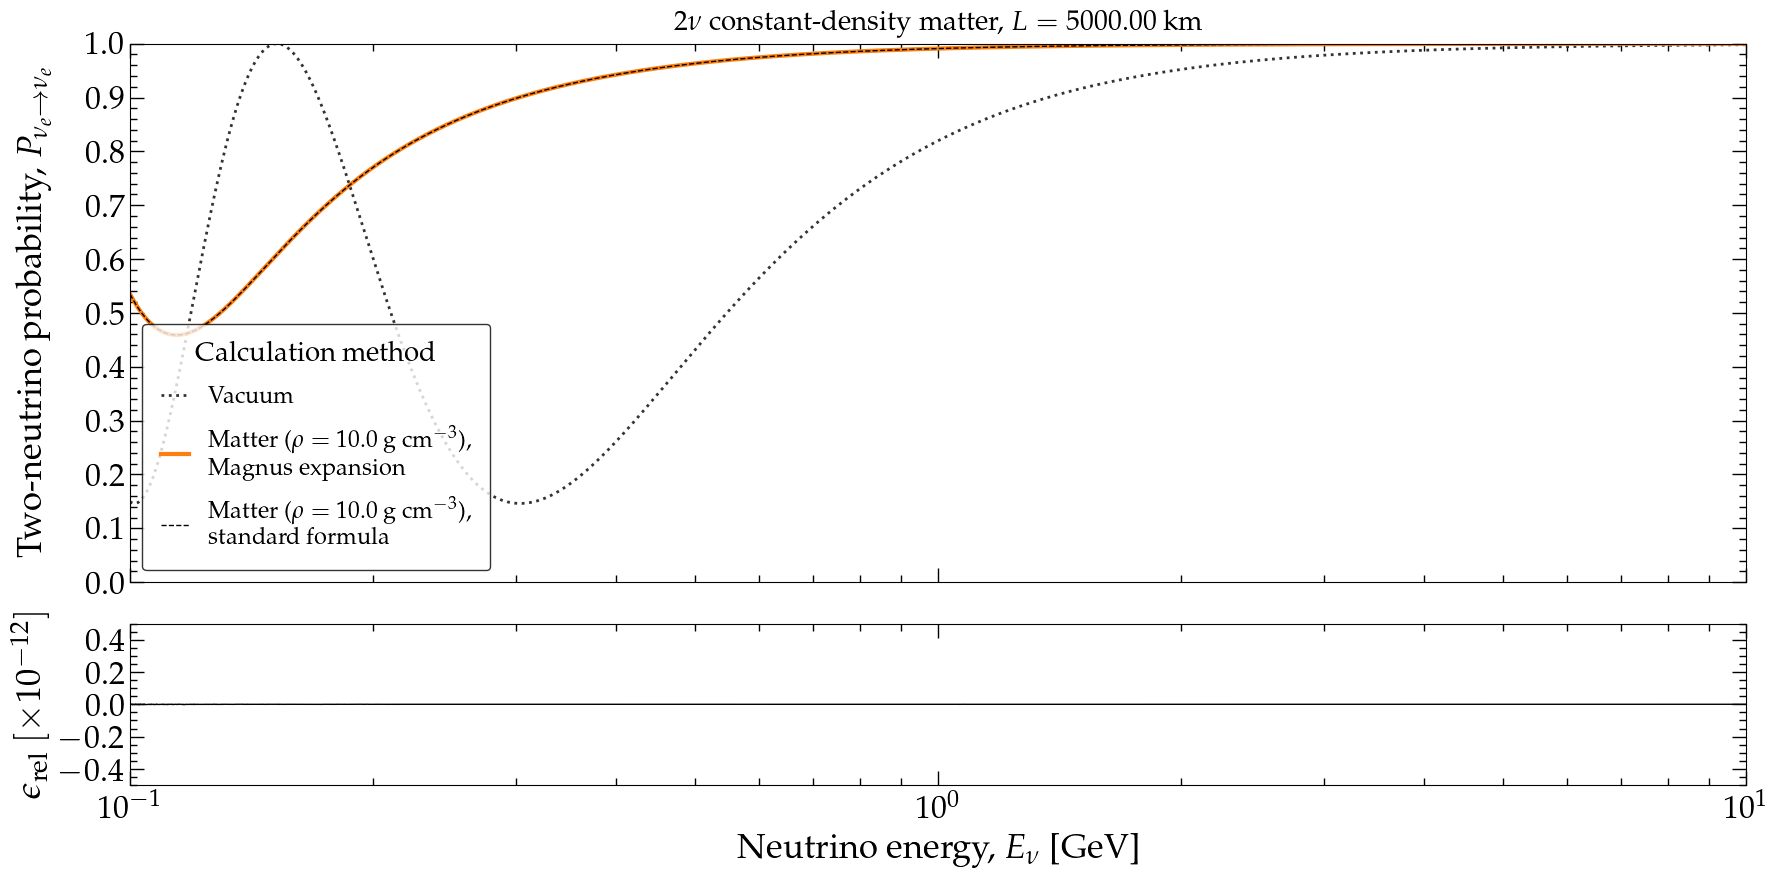

In [14]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', ls=':', lw=2),
     dict(y=prob_matt, color='C1', lw=3,
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'Magnus expansion'),
     dict(y=prob_matt_std, color='k', ls='--',
          label=r'Matter ($\rho = $~{:.1f}'.format(rho)+r'~g~cm$^{-3}$),'+'\n'+'standard formula')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2, energy_unit='GeV',
    xlim=(energy_min, energy_max),
    residual=(prob_matt-prob_matt_std)/prob_matt_std/1.e-12,
    residual_label=r'$\epsilon_{\rm rel}~[\times 10^{-12}]$',
    residual_ylim=(-0.5, 0.5), residual_ymajor=0.20, residual_yminor=0.05,
    legend_title=r'Calculation method', legend_loc='lower left',
    title=r'$2\nu$~constant-density matter, $L = $~{:.2f}~km'.format(baseline),
    savefig='../fig/prob_2nu_matter_vs_energy.pdf')

# 3. Probabilities 2$\nu$: in matter with varying density

## 3.1 General definitions

In [15]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = NUFIT_NO['s12'] # [adim]
Dm2 = NUFIT_NO['D21'] # [eV^2]

In [16]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale = 100.0 # [km]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper.
# [l] = km
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_center) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, exponentially falling density
# --------------------------------------------------------------
# [l] = km
def num_density_e_exp_func(l, num_density_e_center, l_scale):
    return num_density_e_center*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale) # [eV^3]
def VCC_func_exp_density(l, num_density_e_center, l_scale):
    return matter.VCC_func(l, lambda r: num_density_e_exp_func(r, num_density_e_center, l_scale)) # [eV]
def H_func_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density(l, num_density_e_center, l_scale))


# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
# [l] = km
num_density_e_basal = 0*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_central = 8*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_central, l_width = 300.0, 100.0 # [km]
def num_density_e_gaussian_func(l, num_density_e_central, l_central, l_width):
    return num_density_e_basal+num_density_e_central*np.exp( -(l/gd.CONV_KM_TO_INV_EV-l_central)**2/(2.0*l_width**2)) # [eV^3]
def VCC_func_gaussian_density(l, num_density_e_central, l_central, l_width):
    return matter.VCC_func(l, lambda r: num_density_e_gaussian_func(r, num_density_e_central, l_central, l_width)) # [eV]
def H_func_gaussian_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_gaussian_density(l, 
                                                    num_density_e_central, l_central, l_width)) # [eV]

## 3.2 Probabilities vs. distance

### Generate probabilities

In [17]:
# Baselines
l_ini, l_fin = 5.e1, 1.e3 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 10.0*gd.UNIT_MEV # [eV]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, exponentially falling density
# --------------------------------------------------------------
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, energy), 
                                                   0, l*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
prob_matt_gaussian_density = np.array([oscprob.osc_prob(lambda l: H_func_gaussian_density(l, energy), 
                                                        0, l*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=10, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
H_vac = (1./energy)*H_vac_energy_indep # Can also call hamiltonians.hamiltonian_2nu_vacuum instead
prob_vac = np.array([oscprob.osc_prob(lambda l: H_vac,
                                      0.0, l*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

### Plot probabilities

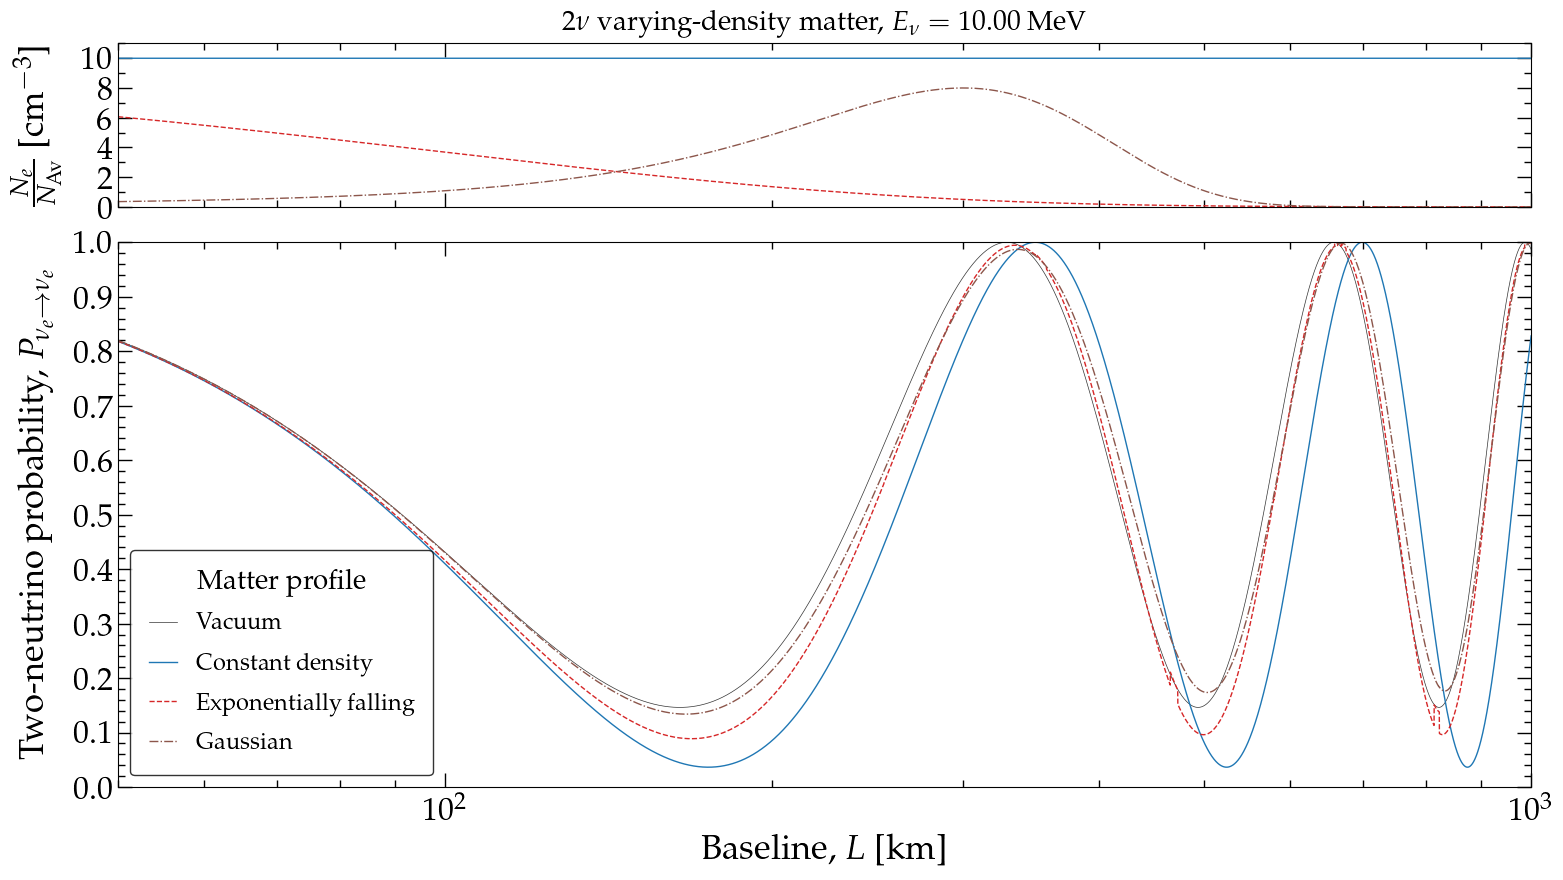

In [18]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center/norm for l in distances], color='C0'),
     dict(y=[num_density_e_exp_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center, l_scale)/norm
             for l in distances], color='C3', ls='--'),
     dict(y=[num_density_e_gaussian_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_central,
                                         l_central, l_width)/norm
             for l in distances], color='C5', ls='-.')],
    [[dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
      dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
      dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
      dict(y=prob_matt_gaussian_density, label=r'Gaussian', color='C5', ls='-.')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 11),
    profile_ymajor=2, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]',
    title=r'$2\nu$~varying-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    title_fontsize=20, ylabel_labelpad=15,
    legend_title=r'Matter profile', legend_loc='lower left', grid=False)

## 3.3 Probabilities vs. energy

### Generate probabilities

In [19]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [MeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e3 # [km]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV), 
                                                     0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, exponeitally falling density
# --------------------------------------------------------------
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV), 
                                                   0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=20, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In matter, Gaussian density
# --------------------------------------------------------------
prob_matt_gaussian_density = np.array([oscprob.osc_prob(lambda l: H_func_gaussian_density(l, enu*gd.UNIT_MEV), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=20, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep, 
                                      0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

### Plot probabilities

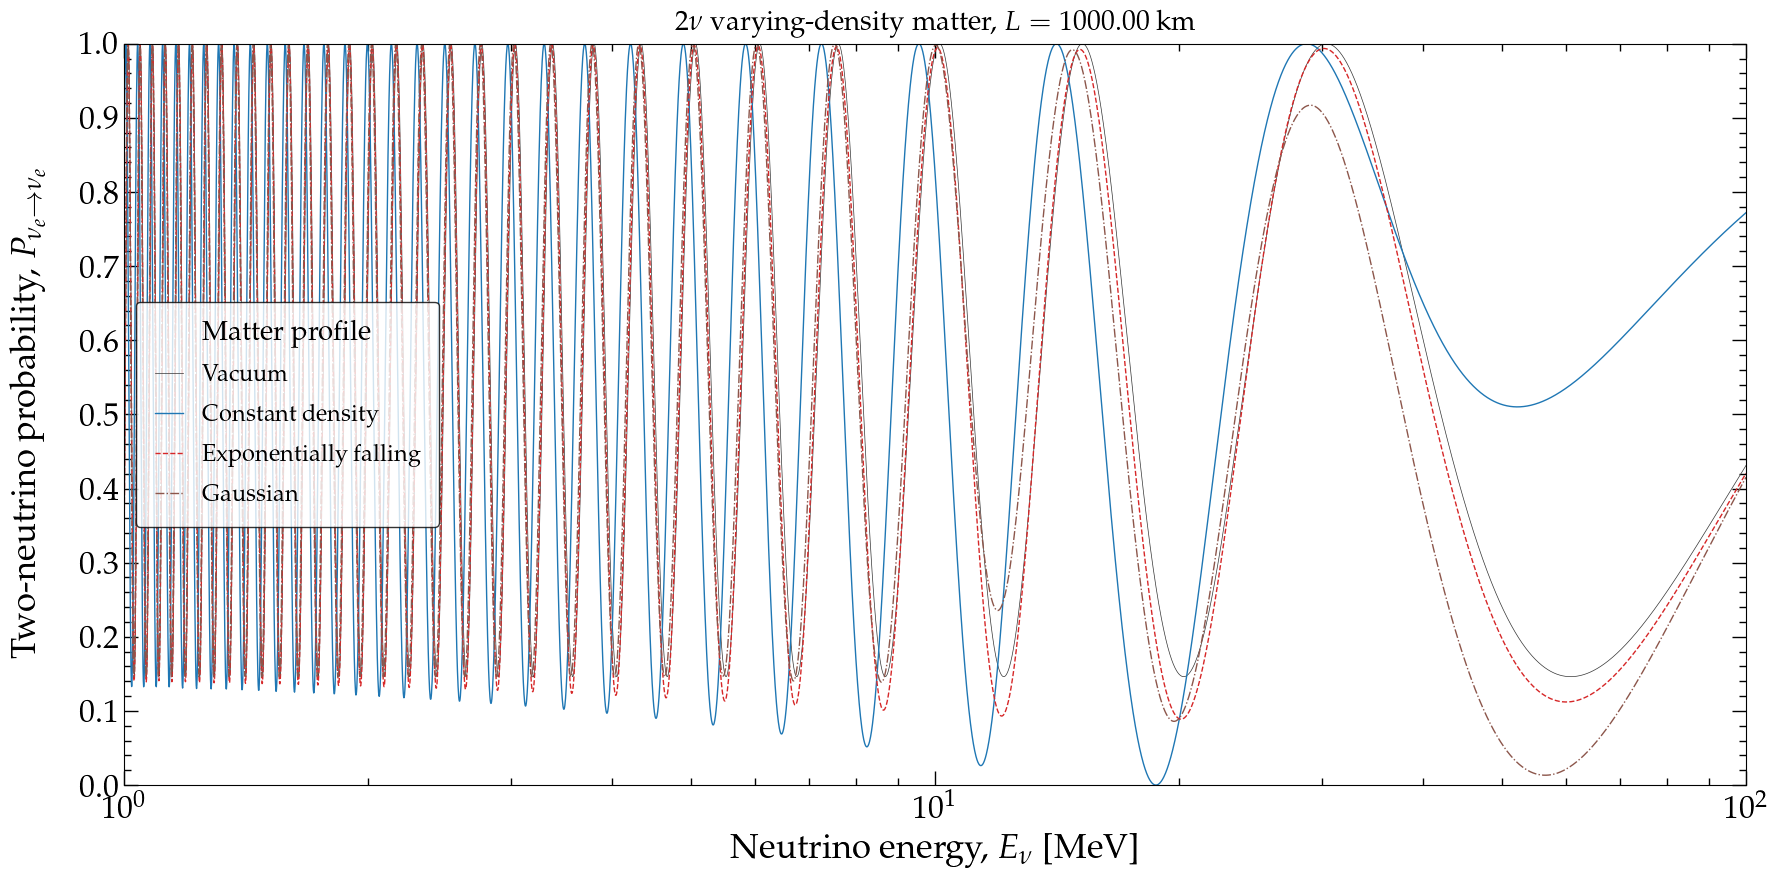

In [20]:
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
     dict(y=prob_matt_const_density, label=r'Constant density', color='C0'),
     dict(y=prob_matt_exp_density, label=r'Exponentially falling', color='C3', ls='--'),
     dict(y=prob_matt_gaussian_density, label=r'Gaussian', color='C5', ls='-.')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2, energy_unit='MeV',
    xlim=(energy_min, energy_max),
    legend_title=r'Matter profile', legend_loc='center left',
    title=r'$2\nu$~varying-density matter, $L = $~{:.2f}~km'.format(baseline))

# 4. Probabilities 2$\nu$: in matter with castle-wall density profile

## 4.1 General definitions

In [21]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = NUFIT_NO['s12'] # [adim]
Dm2 = NUFIT_NO['D21'] # [eV^2]

In [22]:
# Low and high densities of the castle-wall density profile
num_density_e_low = 1*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_high = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
num_density_e_avg = (num_density_e_high-num_density_e_low)/2.0 # [eV^3]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]
    
# --------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper ([l] = km)
VCC_avg = matter.VCC_func(0.0, lambda l: num_density_e_avg) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_avg) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, castle-wall density profile
# --------------------------------------------------------------
# [l] = km
def num_density_e_castle_wall_func(l, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    # np.where, not an if/else: the engine evaluates this for a whole array of
    # positions at once, and a Python `if` on an array raises "truth value of an
    # array is ambiguous". Written this way the profile stays array-capable and
    # osc_prob keeps its fast path -- see the note in notebook 01. It still
    # returns a plain number when handed a single position.
    l_scaled = (np.asarray(l)/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
    dl = 1.0/n_castle_slabs # Width of one slab
    index_slab = l_scaled // dl
    # The first slab has low density, the second one has high density, and so on
    return np.where(index_slab % 2 == 0, num_density_e_low, num_density_e_high)
def VCC_func_castle_wall(l, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    return matter.VCC_func(l, lambda r: num_density_e_castle_wall_func(r, num_density_e_low, num_density_e_high, 
                                                                       n_castle_slabs, l_ini, l_fin)) # [eV]
def H_func_castle_wall(l, energy, num_density_e_low, num_density_e_high, n_castle_slabs, l_ini, l_fin):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_castle_wall(l, 
                                                                                        num_density_e_low, num_density_e_high,
                                                                                        n_castle_slabs, l_ini, l_fin))

n_castle_slabs_narrow = 50 # Narrow castle wall
n_castle_slabs_wide = 10   # Wide castle wall

# Positions of the density walls, in eV^-1.  The profile is a step function, and
# high-order quadrature reaches its nominal order only where the Hamiltonian is
# smooth inside each slab -- integrating across a wall costs accuracy that no
# amount of extra slabs cheaply buys back.  Handing these to osc_prob as
# `t_breakpoints` makes them mandatory slab edges, so no slab ever straddles one.
# osc_prob keeps only the breakpoints that fall inside [t_ini, t_fin], so the same
# array can be passed at every baseline of a scan.
#
# Measured over the scans below, against a converged (n_slabs=24000) reference:
# with n_slabs=150 alone the worst point is 1.5e-2 off and 10% of points exceed
# 1e-3; adding the breakpoints gives 1.9e-3 worst and 1.5%, and runs 2.8x faster.
def castle_wall_breakpoints(n_castle_slabs, l_ini, l_fin):
    # Every wall edge, including the two at l_ini and l_fin where the profile switches on and
    # off.  A trajectory starting before l_ini crosses those as well, and a slab straddling an
    # unmarked discontinuity degrades the quadrature no matter how fine the grid becomes: with
    # arange(1, n) -- the interior walls only -- the error sat at 1.6e-2 in probability,
    # bit-identical from n_slabs=4 through 32, against 3.6e-12 once these two are included.
    return (l_ini+np.arange(0, n_castle_slabs+1)*(l_fin-l_ini)/n_castle_slabs) \
        *gd.CONV_KM_TO_INV_EV # [eV^-1]

## 4.2 Probabilities vs. distance

### Generate probabilities

In [23]:
# Baselines
l_ini, l_fin = 1.e2, 1.e4 #1.e2, 1.e5 # [km]
l_npts = 6000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 50.*gd.UNIT_MEV # [eV] #10

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, narrow castle-wall density profile
# --------------------------------------------------------------
# One traversal of the profile answers every baseline: the evolution operator is a
# time-ordered product, so U(0->L2) = U(L1->L2) . U(0->L1) and each requested answer is a
# prefix of the next (cumulative=True).  Its accuracy grid is *inherited* from one adaptive
# call at the longest baseline rather than guessed, which is what makes it safe: measured
# against solve_ivp, the fixed grid this replaces is accurate at most baselines but spikes
# past 1e-3 at a scattered few of them, and error is not monotone in n_slabs.
prob_matt_castle_wall_narrow = oscprob.osc_prob_energy_baseline(
    lambda l: H_func_castle_wall(l, energy, num_density_e_low,
                                num_density_e_high, n_castle_slabs_narrow,
                                l_ini, l_fin), energy, distances*gd.CONV_KM_TO_INV_EV,
    0.0, nu_i, nu_f, cumulative=True,
    n_tpts_per_slab=100, magnus_exp_order=3,
    t_breakpoints=castle_wall_breakpoints(n_castle_slabs_narrow, l_ini, l_fin))

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
# One traversal of the profile answers every baseline: the evolution operator is a
# time-ordered product, so U(0->L2) = U(L1->L2) . U(0->L1) and each requested answer is a
# prefix of the next (cumulative=True).  Its accuracy grid is *inherited* from one adaptive
# call at the longest baseline rather than guessed, which is what makes it safe: measured
# against solve_ivp, the fixed grid this replaces is accurate at most baselines but spikes
# past 1e-3 at a scattered few of them, and error is not monotone in n_slabs.
prob_matt_castle_wall_wide = oscprob.osc_prob_energy_baseline(
    lambda l: H_func_castle_wall(l, energy, num_density_e_low,
                                num_density_e_high, n_castle_slabs_wide,
                                l_ini, l_fin), energy, distances*gd.CONV_KM_TO_INV_EV,
    0.0, nu_i, nu_f, cumulative=True,
    n_tpts_per_slab=100, magnus_exp_order=3,
    t_breakpoints=castle_wall_breakpoints(n_castle_slabs_wide, l_ini, l_fin))

### Plot probabilities

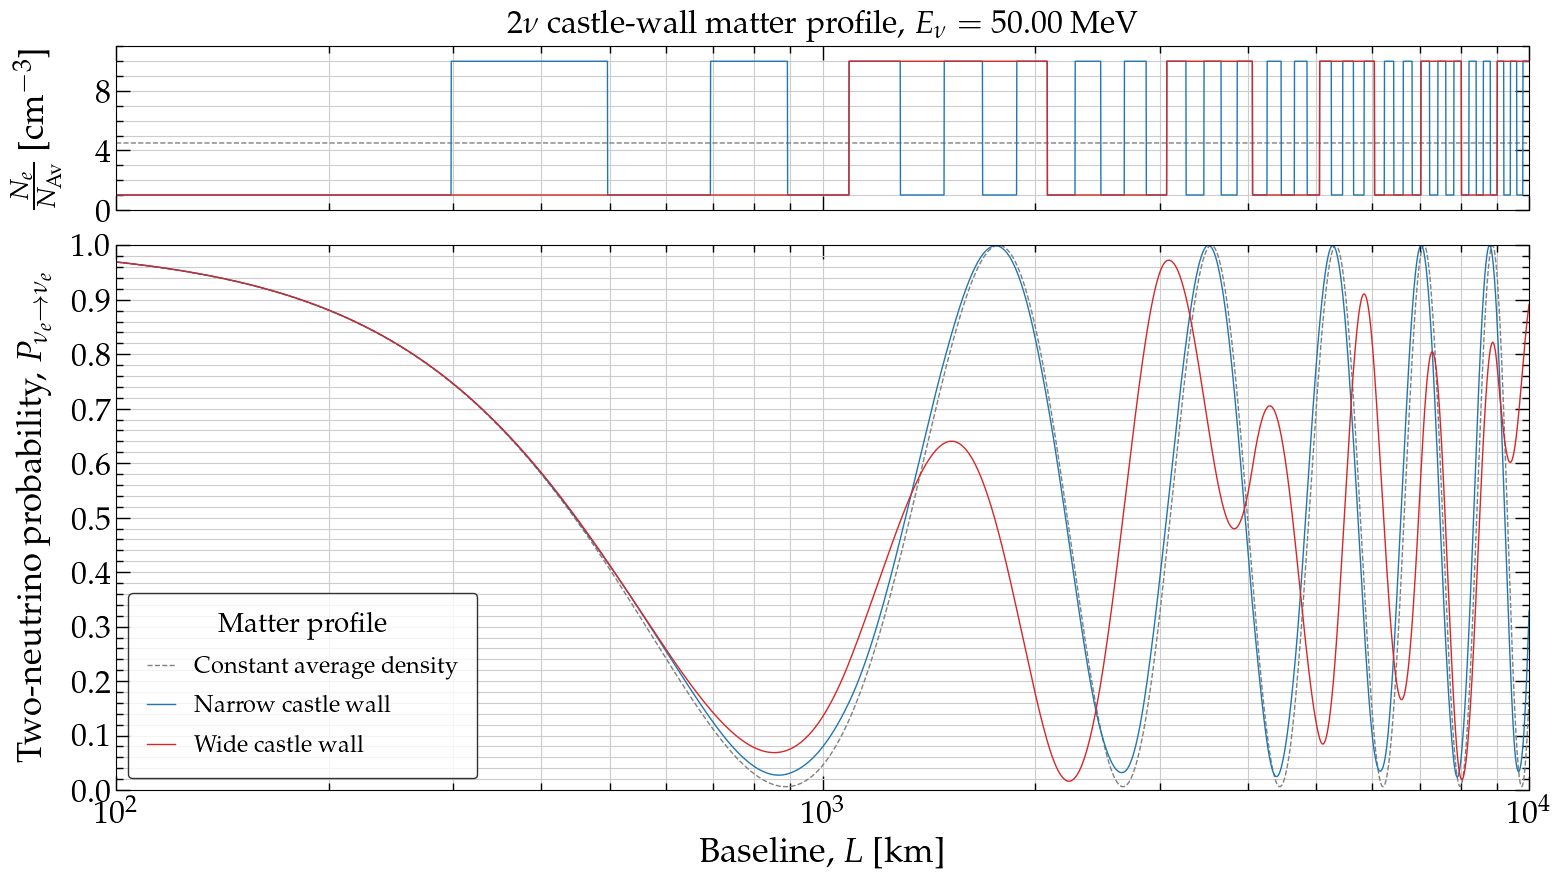

In [24]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_avg/norm for l in distances], color='0.5', ls='--'),
     dict(y=[num_density_e_castle_wall_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_low,
                                            num_density_e_high, n_castle_slabs_narrow, l_ini, l_fin)/norm
             for l in distances], color='C0'),
     dict(y=[num_density_e_castle_wall_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_low,
                                            num_density_e_high, n_castle_slabs_wide, l_ini, l_fin)/norm
             for l in distances], color='C3')],
    [[dict(y=prob_matt_const_density, label=r'Constant average density', color='0.5', ls='--'),
      dict(y=prob_matt_castle_wall_narrow, label=r'Narrow castle wall', color='C0'),
      dict(y=prob_matt_castle_wall_wide, label=r'Wide castle wall', color='C3')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 11),
    profile_ymajor=4, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]',
    title=r'$2\nu$~castle-wall matter profile, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Matter profile', legend_loc='lower left')

## 4.3 Probabilities vs. energy

### Generate probabilities

In [25]:
# Energies
energy_min, energy_max = 1.e0, 1.e3 # [MeV]
energy_npts = 4000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e4 # [km]

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])


# --------------------------------------------------------------
# In matter, narrow castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_narrow = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, enu*gd.UNIT_MEV, 
                                                                                       num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_narrow, l_ini, l_fin), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10,
                                                     t_breakpoints=castle_wall_breakpoints(n_castle_slabs_narrow, l_ini, l_fin))[nu_i][nu_f] \
                                          for enu in energies]) 

# --------------------------------------------------------------
# In matter, wide castle-wall density profile
# --------------------------------------------------------------
prob_matt_castle_wall_wide = np.array([oscprob.osc_prob(lambda l: H_func_castle_wall(l, enu*gd.UNIT_MEV, 
                                                                                       num_density_e_low, num_density_e_high, 
                                                                                       n_castle_slabs_wide, l_ini, l_fin), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10,
                                                     t_breakpoints=castle_wall_breakpoints(n_castle_slabs_wide, l_ini, l_fin))[nu_i][nu_f] \
                                          for enu in energies])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

### Plot probabilities

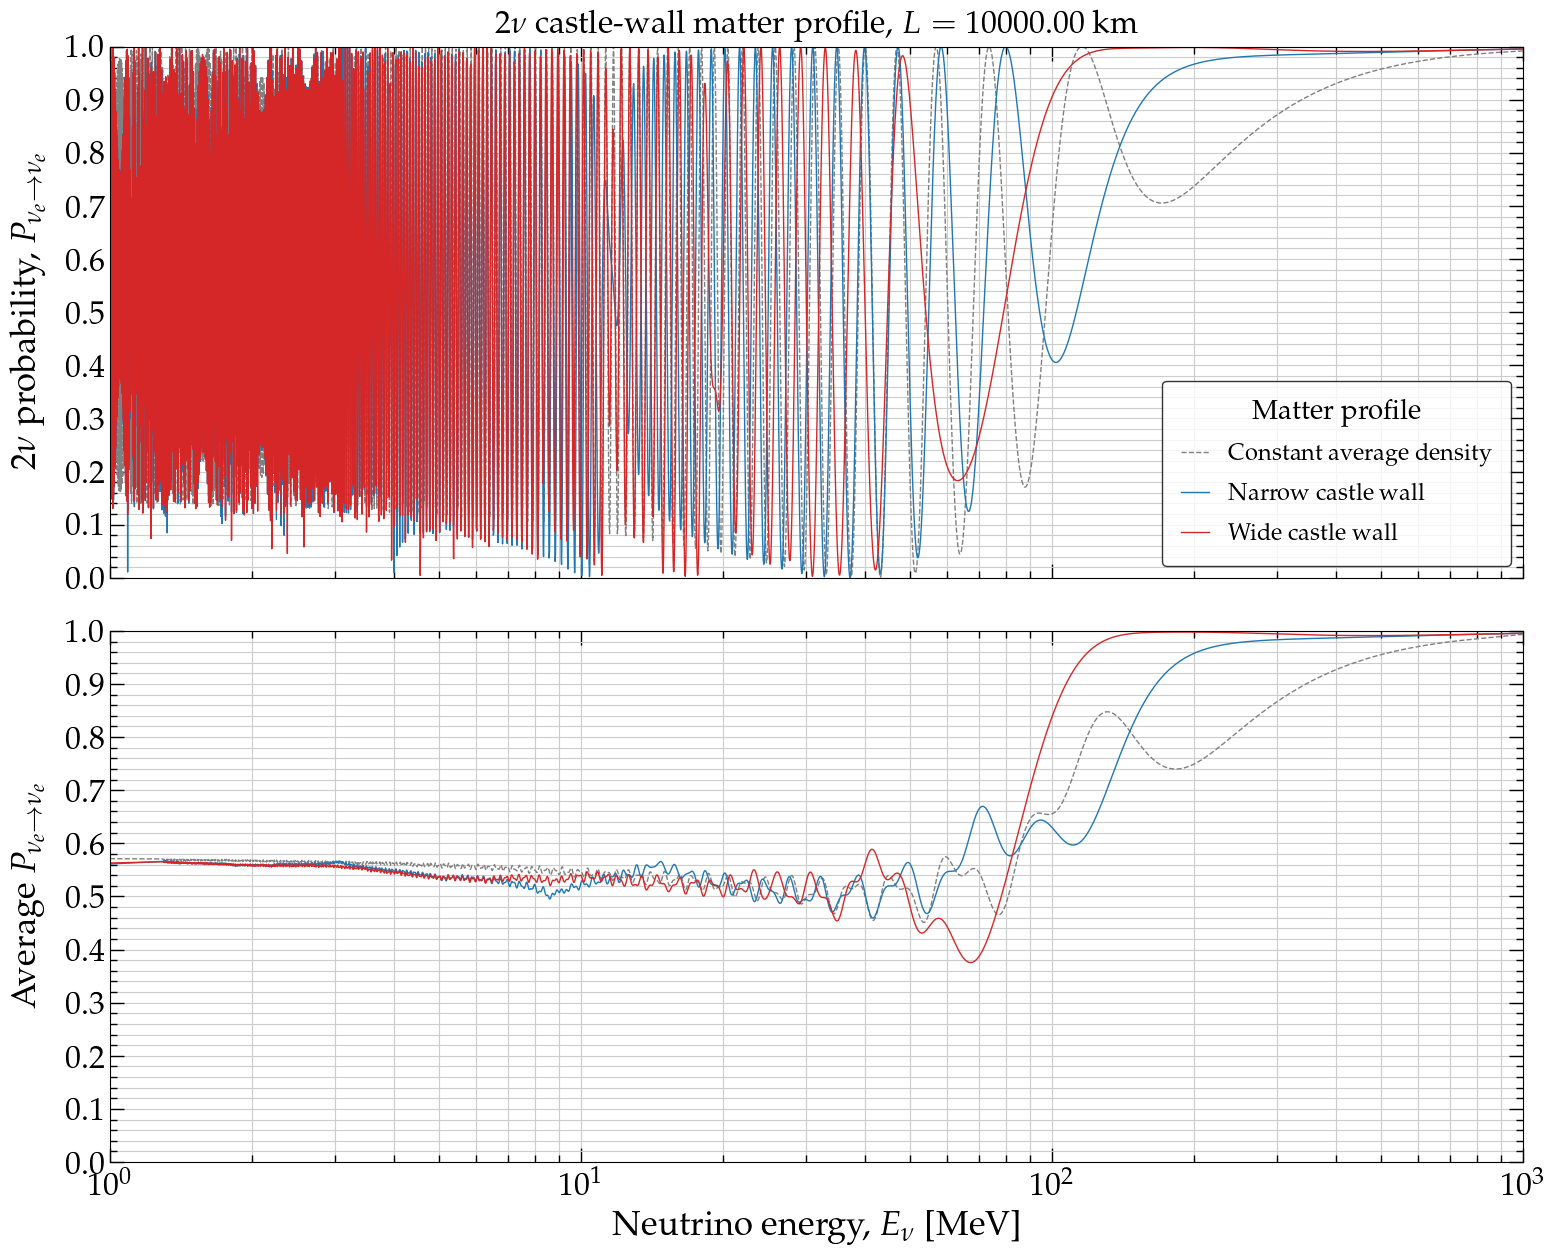

In [26]:
smooth = lambda y: sp.signal.savgol_filter(y, window_length=301, polyorder=1)
fig, ax = plotting.plot_probability_with_profile(
    energies, None,
    [[dict(y=prob_matt_const_density, label=r'Constant average density', color='0.5', ls='--'),
      dict(y=prob_matt_castle_wall_narrow, label=r'Narrow castle wall', color='C0'),
      dict(y=prob_matt_castle_wall_wide, label=r'Wide castle wall', color='C3')],
     [dict(y=smooth(prob_matt_const_density), color='0.5', ls='--'),
      dict(y=smooth(prob_matt_castle_wall_narrow), color='C0'),
      dict(y=smooth(prob_matt_castle_wall_wide), color='C3')]],
    xlim=(energy_min, energy_max), xscale='log',
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Neutrino energy, $E_\nu$ [MeV]',
    title=r'$2\nu$~castle-wall matter profile, $L = $~{:.2f}~km'.format(baseline),
    legend_title=r'Matter profile', legend_loc='lower right', legend_on_panel=0)

# 5. Probabilities 2$\nu$: in matter with noisy density profile

## 5.1 General definitions

In [27]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = NUFIT_NO['s12'] # [adim]
Dm2 = NUFIT_NO['D21'] # [eV^2]

In [28]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center = 10*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale = 100.0 # [km]

# Build the noise
np.random.seed(20)
# High-amplitude, more marked noise
npts_noise = 50 # Use more points to make it more finely noised
x_high = np.linspace(0, 1, npts_noise)
noise_sample_high = np.random.normal(loc=1.0, scale=0.3, size=npts_noise) # Increase scale to increase the width of the noise bumps
noise_mask_high_interp = sp.interpolate.make_interp_spline(x_high, noise_sample_high, k=1)
# Low-amplitude, choppier noise
npts_noise = 300 # Use more points to make it more finely noised
x_low = np.linspace(0, 1, npts_noise)
noise_sample_low = np.random.normal(loc=1.0, scale=0.08, size=npts_noise) # Increase scale to increase the width of the noise bumps
noise_mask_low_interp = sp.interpolate.make_interp_spline(x_low, noise_sample_low, k=1)

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central density
# --------------------------------------------------------------
# The matter density is constant, so this is merely a wrapper.
# [l] = km
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians.hamiltonian_2nu_matter(VCC_center) # [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density

# --------------------------------------------------------------
# In matter, constant density, with noise around central value
# --------------------------------------------------------------
def num_density_e_const_noisy_func(l, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    l_scaled = (l/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
    if noise_model == 'high-amplitude':
        return num_density_e_const*noise_mask_high_interp(l_scaled)
    elif noise_model == 'low-amplitude':
        return num_density_e_const*noise_mask_low_interp(l_scaled)
def VCC_func_const_density_noisy(l, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    return matter.VCC_func(l, lambda r: num_density_e_const_noisy_func(r, num_density_e_const, l_ini, l_fin, 
                                                                       noise_model=noise_model)) # [eV]
def H_func_const_density_noisy(l, energy, num_density_e_const, l_ini, l_fin, noise_model='high-amplitude'):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_noisy(l, num_density_e_const, 
                                                                                                             l_ini, l_fin,
                                                                                                             noise_model=noise_model))
# # --------------------------------------------------------------
# # In matter, exponentially falling density
# # --------------------------------------------------------------
# # [l] = km
# def num_density_e_exp_func(l, num_density_e_center, l_scale):
#     return num_density_e_center*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale) # [eV^3]
# def VCC_func_exp_density(l, num_density_e_center, l_scale):
#     return matter.VCC_func(l, lambda r: num_density_e_exp_func(r, num_density_e_center, l_scale)) # [eV]
# def H_func_exp_density(l, energy):
#     return (1/energy)*H_vac_energy_indep-hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density(l, num_density_e_center, l_scale))

# # --------------------------------------------------------------
# # In matter, exponentially falling density, noisy
# # --------------------------------------------------------------
# # [l] = km
# def num_density_e_exp_noisy_func(l, num_density_e_center, l_scale, l_ini, l_fin):
#     l_scaled = (l/gd.CONV_KM_TO_INV_EV-l_ini)/(l_fin-l_ini)
#     return num_density_e_exp_func(l, num_density_e_center, l_scale)*noise_mask_interp(l_scaled)
# def VCC_func_exp_density_noisy(l, num_density_e_center, l_scale, l_ini, l_fin):
#     return matter.VCC_func(l, lambda r: num_density_e_exp_noisy_func(r, num_density_e_center, l_scale, l_ini, l_fin)) # [eV]
# def H_func_exp_density_noisy(l, energy, num_density_e_center, l_scale, l_ini, l_fin):
#     return (1/energy)*H_vac_energy_indep \
#         - hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_density_noisy(l, num_density_e_center, l_scale, l_ini, l_fin))

## 5.2 Probabilities vs. distance

### Generate probabilities

In [29]:
# Baselines
l_ini, l_fin = 1.e2, 1.e5 # [km]
l_npts = 6000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 50.*gd.UNIT_MEV # [eV] #10

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, energy), 
                                                     0, l*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, constant density, high-amplitude noise
# --------------------------------------------------------------
# One traversal of the profile answers every baseline: the evolution operator is a
# time-ordered product, so U(0->L2) = U(L1->L2) . U(0->L1) and each requested answer is a
# prefix of the next (cumulative=True).  Its accuracy grid is *inherited* from one adaptive
# call at the longest baseline rather than guessed, which is what makes it safe: measured
# against solve_ivp, the fixed grid this replaces is accurate at most baselines but spikes
# past 1e-3 at a scattered few of them, and error is not monotone in n_slabs.
prob_matt_const_density_noisy_high_amplitude = oscprob.osc_prob_energy_baseline(
    lambda l: H_func_const_density_noisy(l, energy, num_density_e_center,
                                        l_ini, l_fin, noise_model='high-amplitude'), energy, distances*gd.CONV_KM_TO_INV_EV,
    0.0, nu_i, nu_f, cumulative=True,
    n_tpts_per_slab=100, magnus_exp_order=3)

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
# One traversal of the profile answers every baseline: the evolution operator is a
# time-ordered product, so U(0->L2) = U(L1->L2) . U(0->L1) and each requested answer is a
# prefix of the next (cumulative=True).  Its accuracy grid is *inherited* from one adaptive
# call at the longest baseline rather than guessed, which is what makes it safe: measured
# against solve_ivp, the fixed grid this replaces is accurate at most baselines but spikes
# past 1e-3 at a scattered few of them, and error is not monotone in n_slabs.
prob_matt_const_density_noisy_low_amplitude = oscprob.osc_prob_energy_baseline(
    lambda l: H_func_const_density_noisy(l, energy, num_density_e_center,
                                        l_ini, l_fin, noise_model='low-amplitude'), energy, distances*gd.CONV_KM_TO_INV_EV,
    0.0, nu_i, nu_f, cumulative=True,
    n_tpts_per_slab=100, magnus_exp_order=3)

# # --------------------------------------------------------------
# # In matter, exponentially falling density
# # --------------------------------------------------------------
# prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, energy), 
#                                                    0, l*gd.CONV_KM_TO_INV_EV, 
#                                                    n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

### Plot probabilities

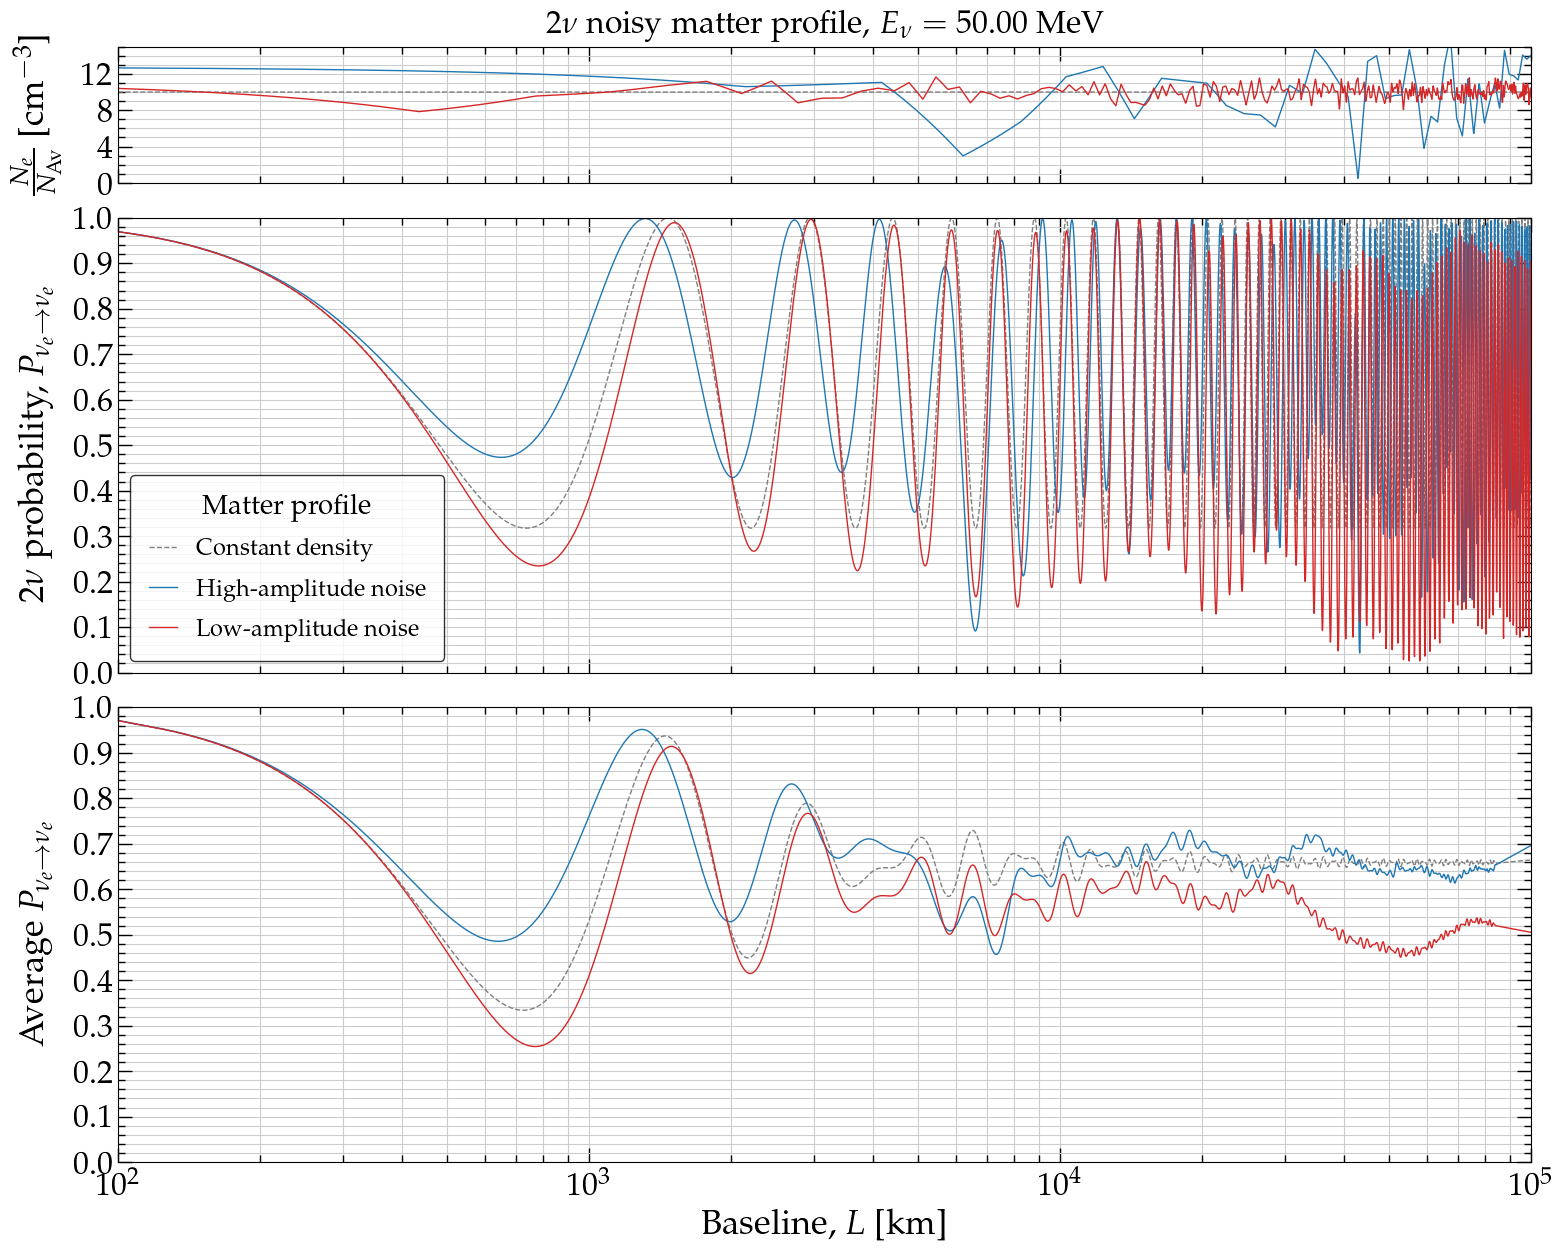

In [30]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
smooth = lambda y: sp.signal.savgol_filter(y, window_length=301, polyorder=1)
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center/norm for l in distances], color='0.5', ls='--'),
     dict(y=[num_density_e_const_noisy_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center,
                                            l_ini, l_fin,
                                            noise_model='high-amplitude')/norm
             for l in distances], color='C0'),
     dict(y=[num_density_e_const_noisy_func(l*gd.CONV_KM_TO_INV_EV, num_density_e_center,
                                            l_ini, l_fin,
                                            noise_model='low-amplitude')/norm
             for l in distances], color='C3')],
    [[dict(y=prob_matt_const_density, label=r'Constant density', color='0.5', ls='--'),
      dict(y=prob_matt_const_density_noisy_high_amplitude, label=r'High-amplitude noise', color='C0'),
      dict(y=prob_matt_const_density_noisy_low_amplitude, label=r'Low-amplitude noise', color='C3')],
     [dict(y=smooth(prob_matt_const_density), color='0.5', ls='--'),
      dict(y=smooth(prob_matt_const_density_noisy_high_amplitude), color='C0'),
      dict(y=smooth(prob_matt_const_density_noisy_low_amplitude), color='C3')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 15),
    profile_ymajor=4, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]', ylabel_labelpad=15,
    title=r'$2\nu$~noisy matter profile, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Matter profile', legend_loc='lower left', legend_on_panel=0)

## 5.3 Probabilities vs. energy

### Generate probabilities

In [31]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 6000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = 1.e5 # [km]

#--------------------------------------------------------------
# In matter, constant density
# --------------------------------------------------------------
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, constant density, high-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_high_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, enu*gd.UNIT_MEV,
                                                                                                            num_density_e_center, 
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='high-amplitude'), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies]) 

# --------------------------------------------------------------
# In matter, constant density, low-amplitude noise
# --------------------------------------------------------------
prob_matt_const_density_noisy_low_amplitude = np.array([oscprob.osc_prob(lambda l: H_func_const_density_noisy(l, enu*gd.UNIT_MEV,
                                                                                                            num_density_e_center,
                                                                                                            l_ini, l_fin,
                                                                                                            noise_model='low-amplitude'), 
                                                     0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=150, n_tpts_per_slab=100, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] \
                                          for enu in energies])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

### Plot probabilities

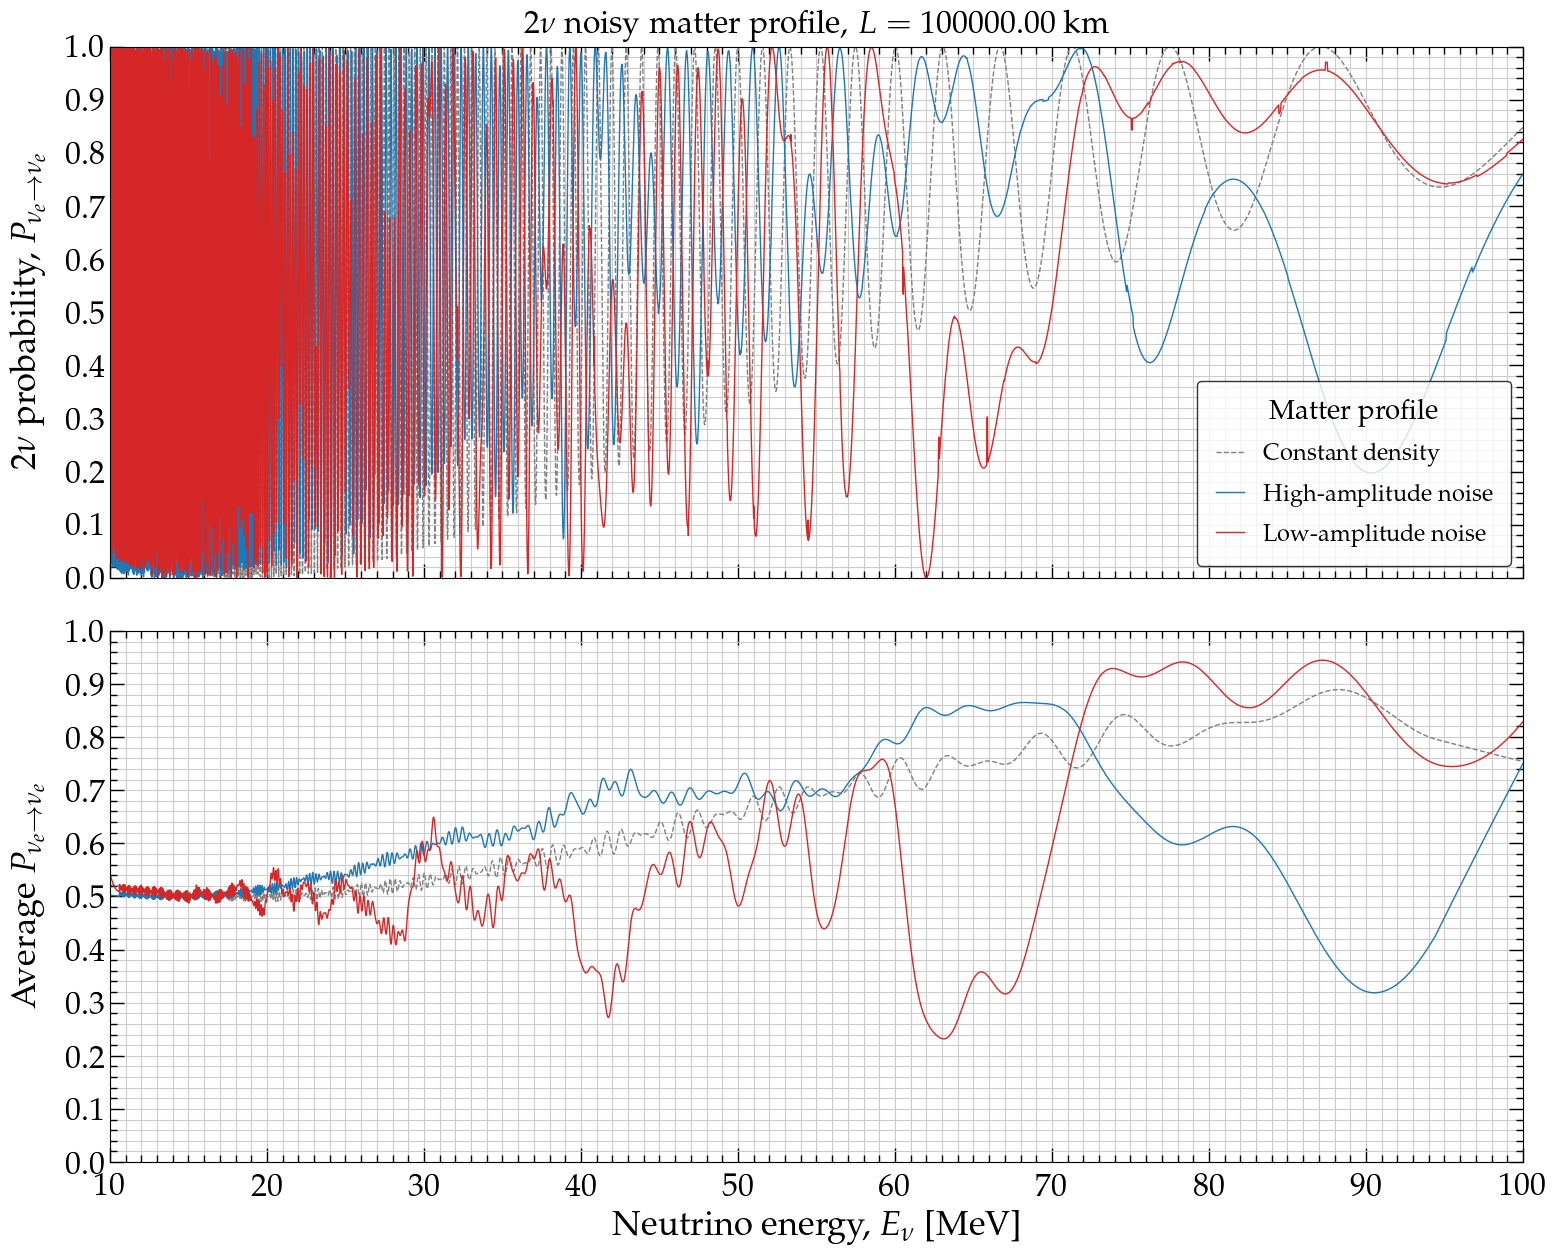

In [32]:
smooth = lambda y, po=1: sp.signal.savgol_filter(y, window_length=301, polyorder=po)
fig, ax = plotting.plot_probability_with_profile(
    energies, None,
    [[dict(y=prob_matt_const_density, label=r'Constant density', color='0.5', ls='--'),
      dict(y=prob_matt_const_density_noisy_high_amplitude, label=r'High-amplitude noise', color='C0'),
      dict(y=prob_matt_const_density_noisy_low_amplitude, label=r'Low-amplitude noise', color='C3')],
     [dict(y=smooth(prob_matt_const_density), color='0.5', ls='--'),
      dict(y=smooth(prob_matt_const_density_noisy_high_amplitude), color='C0'),
      dict(y=smooth(prob_matt_const_density_noisy_low_amplitude, 2), color='C3')]],
    xlim=(energy_min, energy_max), xscale='linear', xmajor=10, xminor=1,
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Neutrino energy, $E_\nu$ [MeV]',
    title=r'$2\nu$~noisy matter profile, $L = $~{:.2f}~km'.format(baseline),
    legend_title=r'Matter profile', legend_loc='lower right', legend_on_panel=0)

# 6. Probabilities 2$\nu$: in the Earth

## 6.1 General definitions

In [33]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = NUFIT_NO['s12'] # [adim]
Dm2 = NUFIT_NO['D21'] # [eV^2]

In [34]:
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # [eV^{-3}]

def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# [l] = km
def H_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_prem(r))

# Test values of the zenith angle, cos(theta_z), to plot, with theta_z = 0 normal to the surface of the Earth, at the position of the
# detector.  All of the direction are upgoing.
costhz_val = [-0.1, -0.5, -1.0]

# Maximum baselines inside the Earth
l_max_val = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_val] # [km]

## 6.2 Probabilities vs. distance

### Generate probabilities

In [35]:
# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]

nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 20.*gd.UNIT_MEV # [eV] #10

l_min = 1.e2 # [km]

# Generate probabilities for the different directions
distances_val, prob_val = [], []
l_npts = 3000
for i in range(len(costhz_val)):
    print("costhz = "+str(costhz_val[i]))
    distances = np.logspace(np.log10(l_min), np.log10(l_max_val[i]), l_npts) # [km]
    distances_val.append(distances)
    # PREM is piecewise-smooth: the density jumps where the chord crosses a shell boundary.
    # Marking those crossings as mandatory slab edges keeps the quadrature from integrating
    # across a discontinuity.  Measured at this grid, against solve_ivp, it costs nothing in
    # time and buys 1.3e3x to 1.9e6x in accuracy -- the costhz = -1 direction was outside the
    # default 1e-3 tolerance without it (4.2e-3 -> 3.3e-6).
    prem_bp = earth.prem_layer_edges_along_chord(costhz_val[i])*gd.UNIT_KM
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_val[i], l, energy), 0, l*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10,
                                      t_breakpoints=prem_bp)[nu_i][nu_f] for l in distances]) 
    prob_val.append(prob)

costhz = -0.1


costhz = -0.5


costhz = -1.0


### Plot probabilities

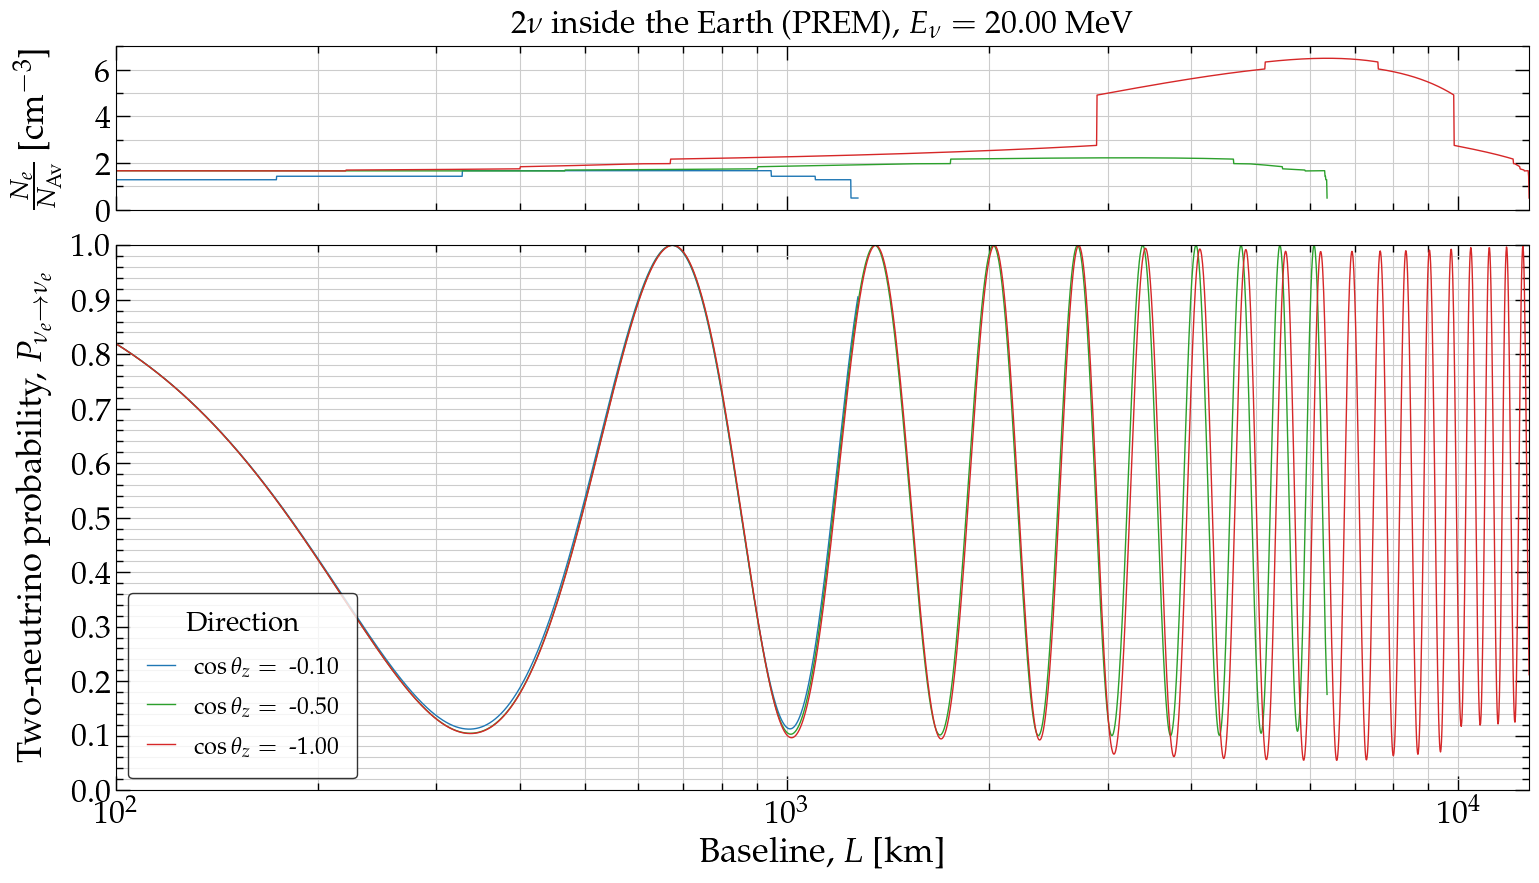

In [36]:
lc = ['C0', 'C2', 'C3']
ls = ['-', '-', '-']
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
profiles, panel = [], []
for i in range(len(costhz_val)):
    n_e = np.array([num_density_e_func_prem(
                        earth.earth_radial_distance_from_depth(costhz_val[i], l))
                    for l in distances_val[i]])/norm
    profiles.append(dict(x=distances_val[i], y=n_e, color=lc[i], ls=ls[i]))
    panel.append(dict(x=distances_val[i], y=prob_val[i], color=lc[i], ls=ls[i],
                      label=r'$\cos \theta_z = $~~{:.2f}'.format(costhz_val[i])))

fig, ax = plotting.plot_probability_with_profile(
    distances_val[0], profiles, [panel],
    xlim=(l_min, max(l_max_val)), profile_ylim=(0, 7),
    profile_ymajor=2, profile_yminor=1, profile_height=0.3,
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L$~[km]',
    title=r'$2\nu$~inside the Earth (PREM), $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    legend_title=r'Direction', legend_loc='lower left')

## 6.3 Probabilities vs. energy

### Generate probabilities

In [37]:
# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 3000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU

# Generate probabilities for the different directions
prob_val = []
for i in range(len(costhz_val)):
    print("costhz = "+str(costhz_val[i]))
    # PREM is piecewise-smooth: the density jumps where the chord crosses a shell boundary.
    # Marking those crossings as mandatory slab edges keeps the quadrature from integrating
    # across a discontinuity.  Measured at this grid, against solve_ivp, it costs nothing in
    # time and buys 1.3e3x to 1.9e6x in accuracy -- the costhz = -1 direction was outside the
    # default 1e-3 tolerance without it (4.2e-3 -> 3.3e-6).
    prem_bp = earth.prem_layer_edges_along_chord(costhz_val[i])*gd.UNIT_KM
    prob = np.array([oscprob.osc_prob(lambda l: H_func_prem(costhz_val[i], l, enu*gd.UNIT_MEV), 
                                      0, l_max_val[i]*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10,
                                      t_breakpoints=prem_bp)[nu_i][nu_f] for enu in energies]) 
    prob_val.append(prob)

costhz = -0.1


costhz = -0.5


costhz = -1.0


### Plot probabilities

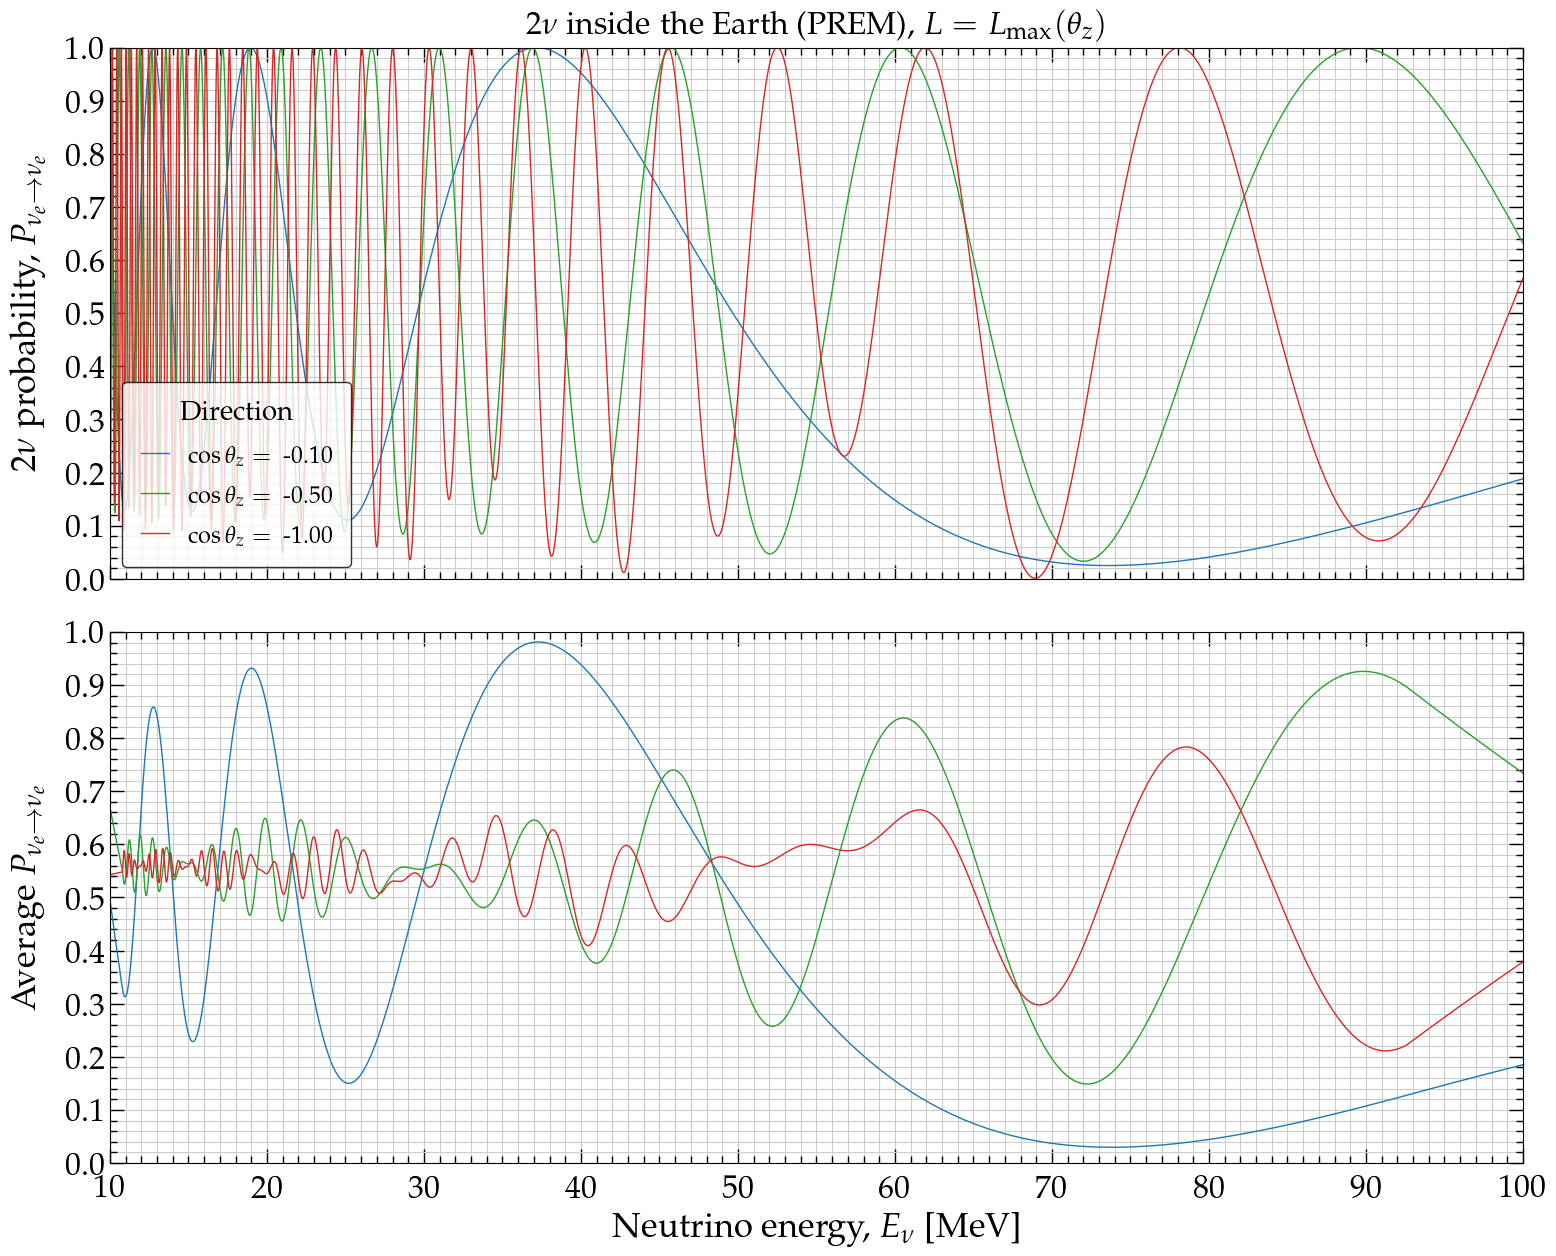

In [38]:
smooth = lambda y: sp.signal.savgol_filter(y, window_length=201, polyorder=1)
fig, ax = plotting.plot_probability_with_profile(
    energies, None,
    [[dict(y=prob_val[i], color=lc[i], ls=ls[i],
           label=r'$\cos \theta_z = $~~{:.2f}'.format(costhz_val[i]))
      for i in range(len(costhz_val))],
     [dict(y=smooth(prob_val[i]), color=lc[i], ls=ls[i])
      for i in range(len(costhz_val))]],
    xlim=(energy_min, energy_max), xscale='linear', xmajor=10, xminor=1,
    panel_ylabels=[r'$2\nu$~probability,~'+plotting.prob_label(nu_i, nu_f),
                   r'Average~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Neutrino energy, $E_\nu$ [MeV]',
    title=r'$2\nu$~inside the Earth (PREM), $L = L_{\rm max}(\theta_z)$',
    legend_title=r'Direction', legend_loc='lower left', legend_on_panel=0)

# 7. Probabilities 2$\nu$: in the Sun

## 7.1 General definitions

In [39]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = NUFIT_NO['s12'] # [adim]
Dm2 = NUFIT_NO['D21'] # [eV^2]

In [40]:
# Parameters for the electron number density in the Sun, Eq. (10.62) in Giunti & Kim
num_density_e_center_sun = 245*gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0) # [eV^3]
l_scale_sun = gd.SUN_RADIUS/10.54 # [km]

# Potential assuming constant density: the matter density is constant, so this is merely a wrapper.
# [l] = km
def num_density_e_sun_const_func(l):
    return num_density_e_center_sun # [eV^3]
def VCC_func_const_density_sun(l):
    return matter.VCC_func(l, num_density_e_sun_const_func) # [eV]

# Potential assuming exponentially decreasing density
# [l] = km
def num_density_e_sun_exp_func(l):
    return num_density_e_center_sun*np.exp(-(l/gd.CONV_KM_TO_INV_EV)/l_scale_sun) # [eV^3]
def VCC_func_exp_sun(l):
    return matter.VCC_func(l, num_density_e_sun_exp_func) # [eV]

## 7.2 Probabilities vs. distance

### Generate probabilities

In [41]:
# Baselines
l_ini, l_fin = 1.e-3, 1.0 # l/SUN_RADIUS
l_npts = 1000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # l/SUN_RADIUS

# Compute probability vs. baseline
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
energy = 5.0*gd.UNIT_MEV # [eV]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_func_const_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      + hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_sun(l))
prob_matt_const_density = np.array([oscprob.osc_prob(H_func_const_density, 
                                                     0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
H_func_exp_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      + hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_sun(l))
# H_func_exp_density = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2) \
                                      # + hamiltonians.hamiltonian_2nu_matter(-VCC_func_exp_sun(l))
# One traversal of the profile answers every baseline: the evolution operator is a
# time-ordered product, so U(0->L2) = U(L1->L2) . U(0->L1) and each requested answer is a
# prefix of the next (cumulative=True).  Its accuracy grid is *inherited* from one adaptive
# call at the longest baseline rather than guessed, which is what makes it safe: measured
# against solve_ivp, the fixed grid this replaces is accurate at most baselines but spikes
# past 1e-3 at a scattered few of them, and error is not monotone in n_slabs.
prob_matt_exp_density = oscprob.osc_prob_energy_baseline(
    H_func_exp_density, energy, distances*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV,
    0.0, nu_i, nu_f, cumulative=True,
    n_tpts_per_slab=100, magnus_exp_order=3)

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
# Using Magnus expansion
H_func = lambda l: hamiltonians.hamiltonian_2nu_vacuum(energy, sth, Dm2)
prob_vac = np.array([oscprob.osc_prob(H_func,
                                      0.0, l*gd.SUN_RADIUS*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for l in distances])
# # Using standard formula
# prob_std = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, energy, l*gd.CONV_KM_TO_INV_EV)[nu_i][nu_f] for l in distances])

/tmp/ipykernel_1757828/3352036167.py:33: ToleranceNotAchievedWarning: osc_prob_energy_baseline (cumulative scan): the accuracy grid was sized from max_n_slabs rather than from a converged requirement -- the probe that sizes it ran out of slabs before it converged. Every baseline in this scan inherits that grid, so the whole scan is affected, not one point. Raise max_n_slabs (currently 20000), or shorten the longest baseline, which is what sets the grid. Shown once per session.
  prob_matt_exp_density = oscprob.osc_prob_energy_baseline(


### Plot probabilities

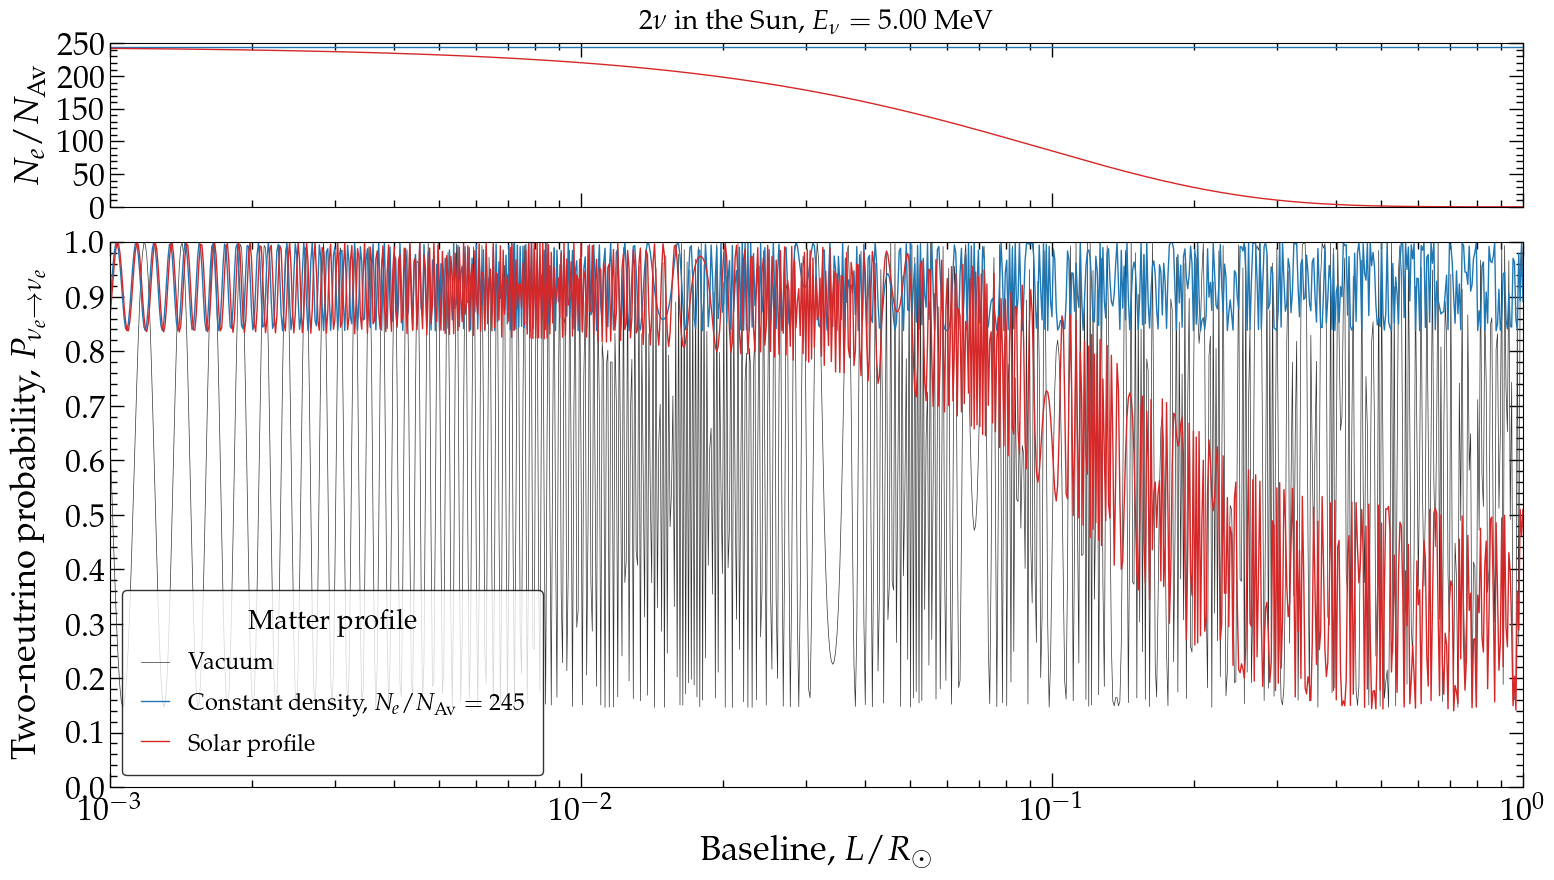

In [42]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_with_profile(
    distances,
    [dict(y=[num_density_e_center_sun/norm for l in distances], color='C0'),
     dict(y=[num_density_e_center_sun/norm*np.exp(-l*gd.SUN_RADIUS/l_scale_sun)
             for l in distances], color='C3')],
    [[dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
      dict(y=prob_matt_const_density, color='C0',
           label=r'Constant density, $N_e/N_{\rm Av} =~$'
                 + '{:.0f}'.format(num_density_e_center_sun/norm)),
      dict(y=prob_matt_exp_density, label=r'Solar profile', color='C3')]],
    xlim=(l_ini, l_fin), profile_ylim=(0, 250),
    profile_ymajor=50, profile_yminor=10, profile_height=0.3,
    profile_ylabel=r'$N_e/N_{\rm Av}$',
    panel_ylabels=[r'Two-neutrino probability,~'+plotting.prob_label(nu_i, nu_f)],
    xlabel=r'Baseline, $L/R_\odot$', ylabel_labelpad=7,
    title=r'$2\nu$~in the Sun, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV),
    title_fontsize=20, legend_title=r'Matter profile', legend_loc='lower left',
    grid=False)

## 7.3 Probabilities vs. energy

### Generate probabilities

In [43]:
# Energies
energy_min, energy_max = 1.e-1, 1.e2 # [MeV]
energy_npts = 1000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
# osc_prob and osc_prob_2nu_vacuum_std return a 2x2 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU
baseline = gd.SUN_RADIUS # [km]

H_vac_energy_indep = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # Vacuum H without (1/E) [eV^2]

# --------------------------------------------------------------
# In matter, constant density equal to central solar density
# --------------------------------------------------------------
H_matt = hamiltonians.hamiltonian_2nu_matter(VCC_func_const_density_sun(0.0)) # Matter Hamiltonian [eV]
def H_func_const_density(l, energy):
    return (1/energy)*H_vac_energy_indep+H_matt
prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV), 
                                                     0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                     n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

# --------------------------------------------------------------
# In matter, solar matter density profile
# --------------------------------------------------------------
def H_func_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians.hamiltonian_2nu_matter(VCC_func_exp_sun(l)) 
prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV), 
                                                   0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                   n_slabs=200, n_tpts_per_slab=100, magnus_exp_order=2, n_jobs=10)[nu_i][nu_f] \
                                                   # n_slabs=200, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=8)[nu_i][nu_f] \
                                  for enu in energies])

# --------------------------------------------------------------
# In vacuum
# --------------------------------------------------------------
prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep, 
                                      0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1)[nu_i][nu_f] for enu in energies])

/tmp/ipykernel_1757828/2392756941.py:19: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), with no two levels to compare, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),


/tmp/ipykernel_1757828/2392756941.py:19: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), the last two refinement levels still differing by a few times the tolerance, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  prob_matt_const_density = np.array([oscprob.osc_prob(lambda l: H_func_const_density(l, enu*gd.UNIT_MEV),


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by more than a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators

/tmp/ipykernel_1757828/2392756941.py:28: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), the last two refinement levels still differing by a few times the tolerance, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  prob_matt_exp_density = np.array([oscprob.osc_prob(lambda l: H_func_exp_density(l, enu*gd.UNIT_MEV),


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1761: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

/tmp/ipykernel_1757828/2392756941.py:37: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), with no two levels to compare, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep,


/tmp/ipykernel_1757828/2392756941.py:37: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), the last two refinement levels still differing by a few times the tolerance, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  prob_vac = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_MEV))*H_vac_energy_indep,


### Plot probabilities

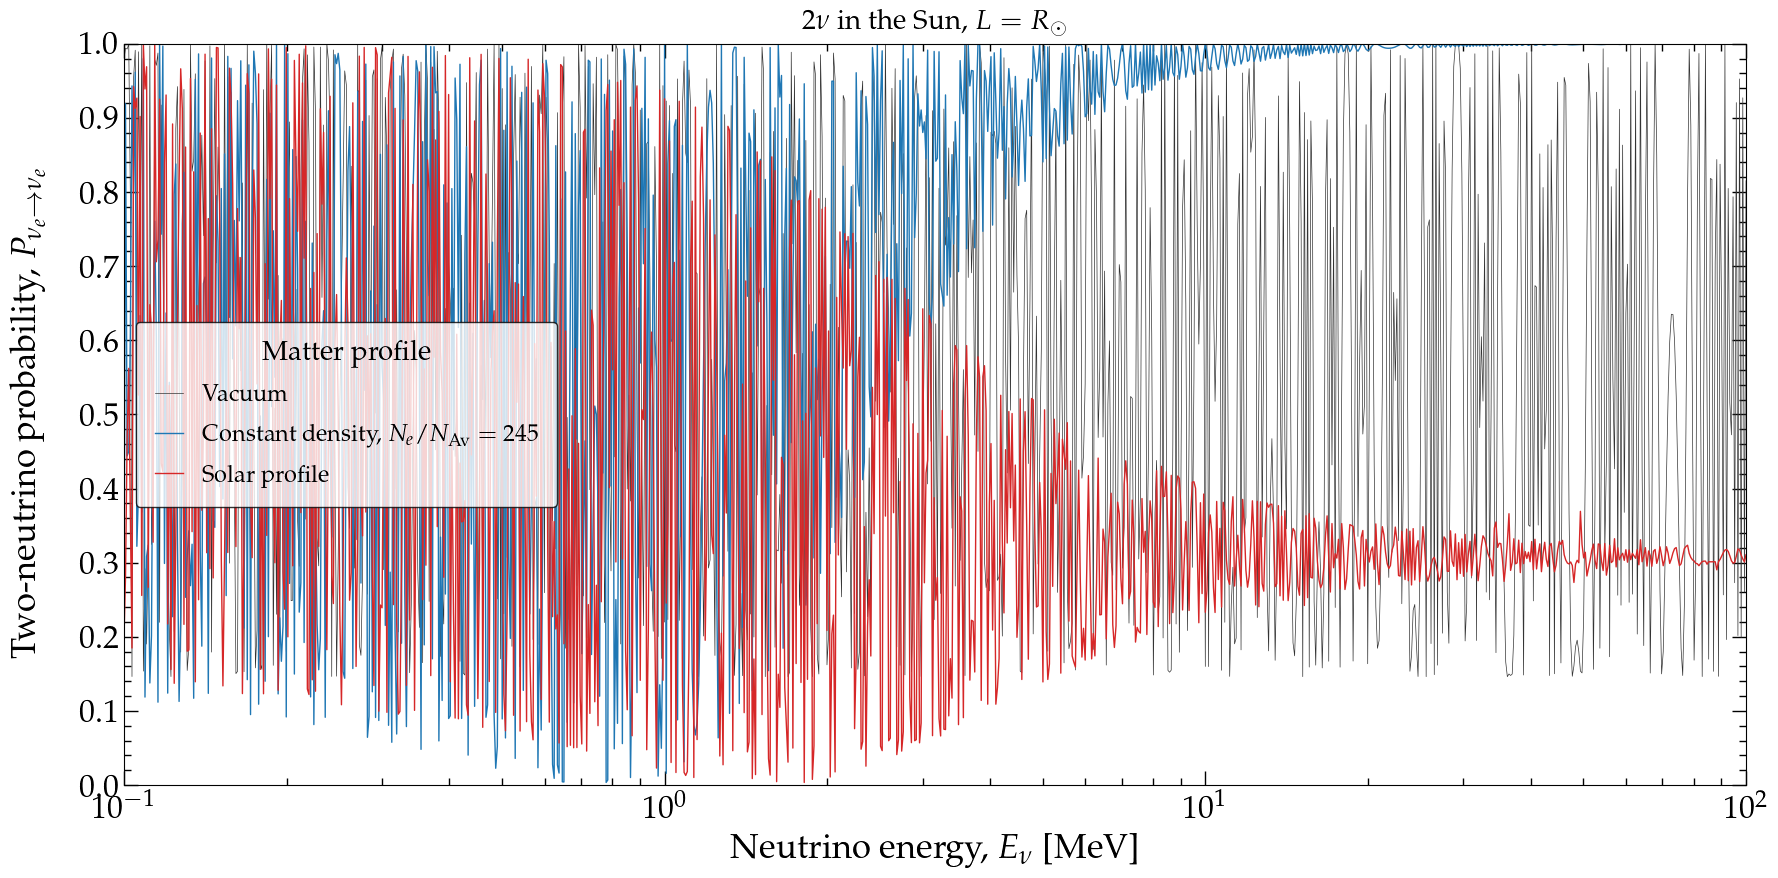

In [44]:
norm = (gd.N_AV/pow(gd.CONV_CM_TO_INV_EV,3.0))
fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_vac, label=r'Vacuum', color='0.2', lw=0.5),
     dict(y=prob_matt_const_density, color='C0',
          label=r'Constant density, $N_e/N_{\rm Av} =~$'
                + '{:.0f}'.format(num_density_e_center_sun/norm)),
     dict(y=prob_matt_exp_density, label=r'Solar profile', color='C3')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=2, energy_unit='MeV',
    xlim=(energy_min, energy_max),
    legend_title=r'Matter profile', legend_loc='center left',
    title=r'$2\nu$~in the Sun, $L = R_\odot$')

---

**Previous:** [Introduction](01_magnus_introduction.ipynb)  
**Next:** [Three-neutrino probabilities](03_magnus_3nu_vacuum_matter.ipynb) --- the same ground with three flavours and a CP phase  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)